<a href="https://colab.research.google.com/github/Onureeva/airbnb-vienna-nlp-pricing/blob/main/Final_Project_661_start_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Exploratory Data Analysis

### Importing the required Libraries and the Dataset

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy import stats


In [ ]:
# import datasets
listings_url = 'https://data.insideairbnb.com/austria/vienna/vienna/2025-09-14/data/listings.csv.gz'

reviews_url = 'https://data.insideairbnb.com/austria/vienna/vienna/2025-09-14/data/reviews.csv.gz'

# Load the datasets into DataFrames
listings_df = pd.read_csv(listings_url, compression='gzip')

reviews_df = pd.read_csv(reviews_url, compression='gzip')



In [ ]:
!pip install gdown
import gdown
import pandas as pd
file_id="1_47UIZZ4tFXtrCTaCJc3vkjLu7v29Lrf"
url="https://drive.google.com/uc?export=download&id=" + file_id
gdown.download(url, 'cleaned_reviews.csv', quiet=False)

df_cleaned = pd.read_csv('cleaned_reviews.csv')

# examine the first few lines of the data set
df_cleaned.head()

Downloading...
From: https://drive.google.com/uc?export=download&id=1_47UIZZ4tFXtrCTaCJc3vkjLu7v29Lrf
To: /content/cleaned_reviews.csv
100%|██████████| 86.0M/86.0M [00:00<00:00, 119MB/s]


,listing_id,date,comments,language,review_length
0,40625,2010-08-04,ingela is a superb host she personally welcom...,en,80
1,40625,2010-10-03,ingela was a perfect host she gave great direc...,en,61
2,40625,2011-03-22,our stay in vienna with ingela could not have ...,en,103
3,40625,2011-09-21,our stay in the beautiful city of vienna was g...,en,98
4,40625,2011-10-01,we really enjoyed our visit and loved the very...,en,26


## Data Cleaning (Reviews Dataset)

In [ ]:
#Please use the link below to access the colab file for the reviews cleaning and analysis.
#This was done separately as the reveiws data loads very slowly.
# https://drive.google.com/file/d/1izE0iuUXv55_1LFI0viDYRIOTUWdJ_Mb/view?usp=sharing


## Data Cleaning (Listing Dataset)

In [ ]:
#Listing the top 5 rows of tthe dataset
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40625,https://www.airbnb.com/rooms/40625,20250914152932,2025-09-14,city scrape,"Near Palace Schönbrunn, Apt. 1",Welcome to my Apt. 1!<br /><br />This is a 2be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/11509144/d55c...,175131,...,4.94,4.61,4.73,NaN,f,14,13,1,0,1.22
1,51287,https://www.airbnb.com/rooms/51287,20250914152932,2025-09-14,city scrape,little studio- next to citycenter- wifi- nice ...,small studio in new renovated old house and ve...,The neighbourhood has a lot of very nice littl...,https://a0.muscache.com/pictures/25163038/1c4e...,166283,...,4.95,4.87,4.59,NaN,f,2,2,0,0,2.15
2,109679,https://www.airbnb.com/rooms/109679,20250914152932,2025-09-14,city scrape,Near Palace Schönbrunn - Apt. 4,Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/1982234/1fc34...,175131,...,4.92,4.66,4.82,NaN,f,14,13,1,0,0.93
3,114505,https://www.airbnb.com/rooms/114505,20250914152932,2025-09-14,city scrape,"Near Palace Schönbrunn, Apt. 5",Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/11536257/9065...,175131,...,4.96,4.71,4.80,NaN,f,14,13,1,0,0.71
4,131628,https://www.airbnb.com/rooms/131628,20250914152932,2025-09-15,previous scrape,"Holiday Apartment ""Modern Vienna""",Modern ambiance in a turn of the century house...,"Bakerys, Viennese wine taverns (“Heurige“) wit...",https://a0.muscache.com/pictures/35385584/a900...,647465,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN


In [ ]:
#Checking the number of rows and columns in the dataset
listings_df.shape

(14123, 79)

In [ ]:
# Listing the names of all the columns.
listings_df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [ ]:
listings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14123 entries, 0 to 14122
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14123 non-null  int64  
 1   listing_url                                   14123 non-null  object 
 2   scrape_id                                     14123 non-null  int64  
 3   last_scraped                                  14123 non-null  object 
 4   source                                        14123 non-null  object 
 5   name                                          14123 non-null  object 
 6   description                                   13704 non-null  object 
 7   neighborhood_overview                         6407 non-null   object 
 8   picture_url                                   14122 non-null  object 
 9   host_id                                       14123 non-null 

In [ ]:
# Checking Duplicate rows
listings_df[listings_df.duplicated()]
# to remove the duplicate columns
# listings_df.drop_duplicates(inplace = True)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [ ]:
missing_perc = listings_df.isna().sum()/len(listings_df) * 100
# Filtering for values > 0 and sorting them from highest to lowest
missing_perc[missing_perc > 0].sort_values(ascending=False)

,0
calendar_updated,100.000000
license,100.000000
neighbourhood_group_cleansed,100.000000
host_neighbourhood,62.777030
neighborhood_overview,54.634285
neighbourhood,54.634285
host_about,51.547122
host_location,27.062239
estimated_revenue_l365d,27.026836
price,27.026836


Since the number of columns are a lot, we eliminate the the text based columns which have no relation to the analysis.

Since the price Column has around 27% of the missing values, removing the rows would be a better alternative as populating the missing rows with mean/median/mode will not help us in our analysis (the price of each property is different)

In [ ]:
listings_df.dropna(subset=['price'], inplace = True)

In [ ]:
missing_perc1 = listings_df.isna().sum()/len(listings_df) * 100
# Filtering for values > 0 and sorting them from highest to lowest
missing_perc1[missing_perc1 > 0].sort_values(ascending=False)

,0
calendar_updated,100.000000
neighbourhood_group_cleansed,100.000000
license,100.000000
host_neighbourhood,68.397050
neighborhood_overview,54.230545
neighbourhood,54.230545
host_about,49.019988
host_location,28.827867
review_scores_value,13.661944
reviews_per_month,13.661944


In [ ]:
listings_df.shape

(10306, 79)

In [ ]:
# Dropping columns more than 50% of missing values.
# (calendar_updated, neighbourhood_group_cleansed, license, host_neighbourhood, neighborhood_overview, neighbourhood, host_about)
Columns_to_Drop = missing_perc1[missing_perc1 > 40].index.tolist()
listings_df.drop(columns = Columns_to_Drop, inplace = True)

In [ ]:
listings_df.shape

(10306, 72)

In [ ]:
# Dropping the columns which are irrelavant to our analysis.
Columns_to_Drop1 = ['listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped','bathrooms_text']

listings_df.drop(columns = Columns_to_Drop1, inplace = True)

In [ ]:
listings_df.shape

(10306, 34)

In [ ]:
listings_df.isna().mean()*100

,0
id,0.000000
neighbourhood_cleansed,0.000000
latitude,0.000000
longitude,0.000000
property_type,0.000000
room_type,0.000000
accommodates,0.000000
bathrooms,0.029109
bedrooms,0.329905
beds,0.048515


In [ ]:
#Dropping the tiny number of rows with missing bed/bath values
listings_df.dropna(subset=['bathrooms'], inplace = True)
listings_df.dropna(subset=['bedrooms'], inplace = True)
listings_df.dropna(subset=['beds'], inplace = True)

In [ ]:
listings_df.head(20)

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40625,Rudolfsheim-Fnfhaus,48.184340,16.327010,Entire rental unit,Entire home/apt,6,1.0,2.0,3.0,...,4.89,4.94,4.61,4.73,f,14,13,1,0,1.22
1,51287,Leopoldstadt,48.217780,16.378470,Entire rental unit,Entire home/apt,2,1.0,0.0,2.0,...,4.92,4.95,4.87,4.59,f,2,2,0,0,2.15
2,109679,Rudolfsheim-Fnfhaus,48.184670,16.327950,Entire rental unit,Entire home/apt,4,1.0,0.0,4.0,...,4.91,4.92,4.66,4.82,f,14,13,1,0,0.93
3,114505,Rudolfsheim-Fnfhaus,48.184450,16.327220,Entire rental unit,Entire home/apt,4,1.0,0.0,3.0,...,4.96,4.96,4.71,4.80,f,14,13,1,0,0.71
5,138264,Hernals,48.223530,16.317730,Entire condo,Entire home/apt,4,1.0,1.0,2.0,...,5.00,5.00,5.00,4.17,t,14,14,0,0,0.07
6,169672,Wieden,48.195270,16.363740,Private room in rental unit,Private room,2,1.0,1.0,1.0,...,4.81,4.76,4.91,4.77,f,1,0,1,0,2.59
7,169752,Margareten,48.194690,16.359630,Entire rental unit,Entire home/apt,3,1.0,0.0,1.0,...,4.96,4.94,4.96,4.75,t,11,11,0,0,0.89
9,171835,Wieden,48.195710,16.375010,Entire rental unit,Entire home/apt,3,1.0,2.0,2.0,...,4.91,4.90,4.95,4.73,f,1,1,0,0,1.15
10,172530,Margareten,48.194690,16.359630,Entire rental unit,Entire home/apt,7,1.5,3.0,4.0,...,4.95,4.93,4.80,4.63,t,11,11,0,0,1.42
11,173375,Leopoldstadt,48.216640,16.378420,Entire rental unit,Entire home/apt,4,1.0,1.0,2.0,...,4.89,4.84,4.79,4.81,f,1,1,0,0,1.68


<Axes: >

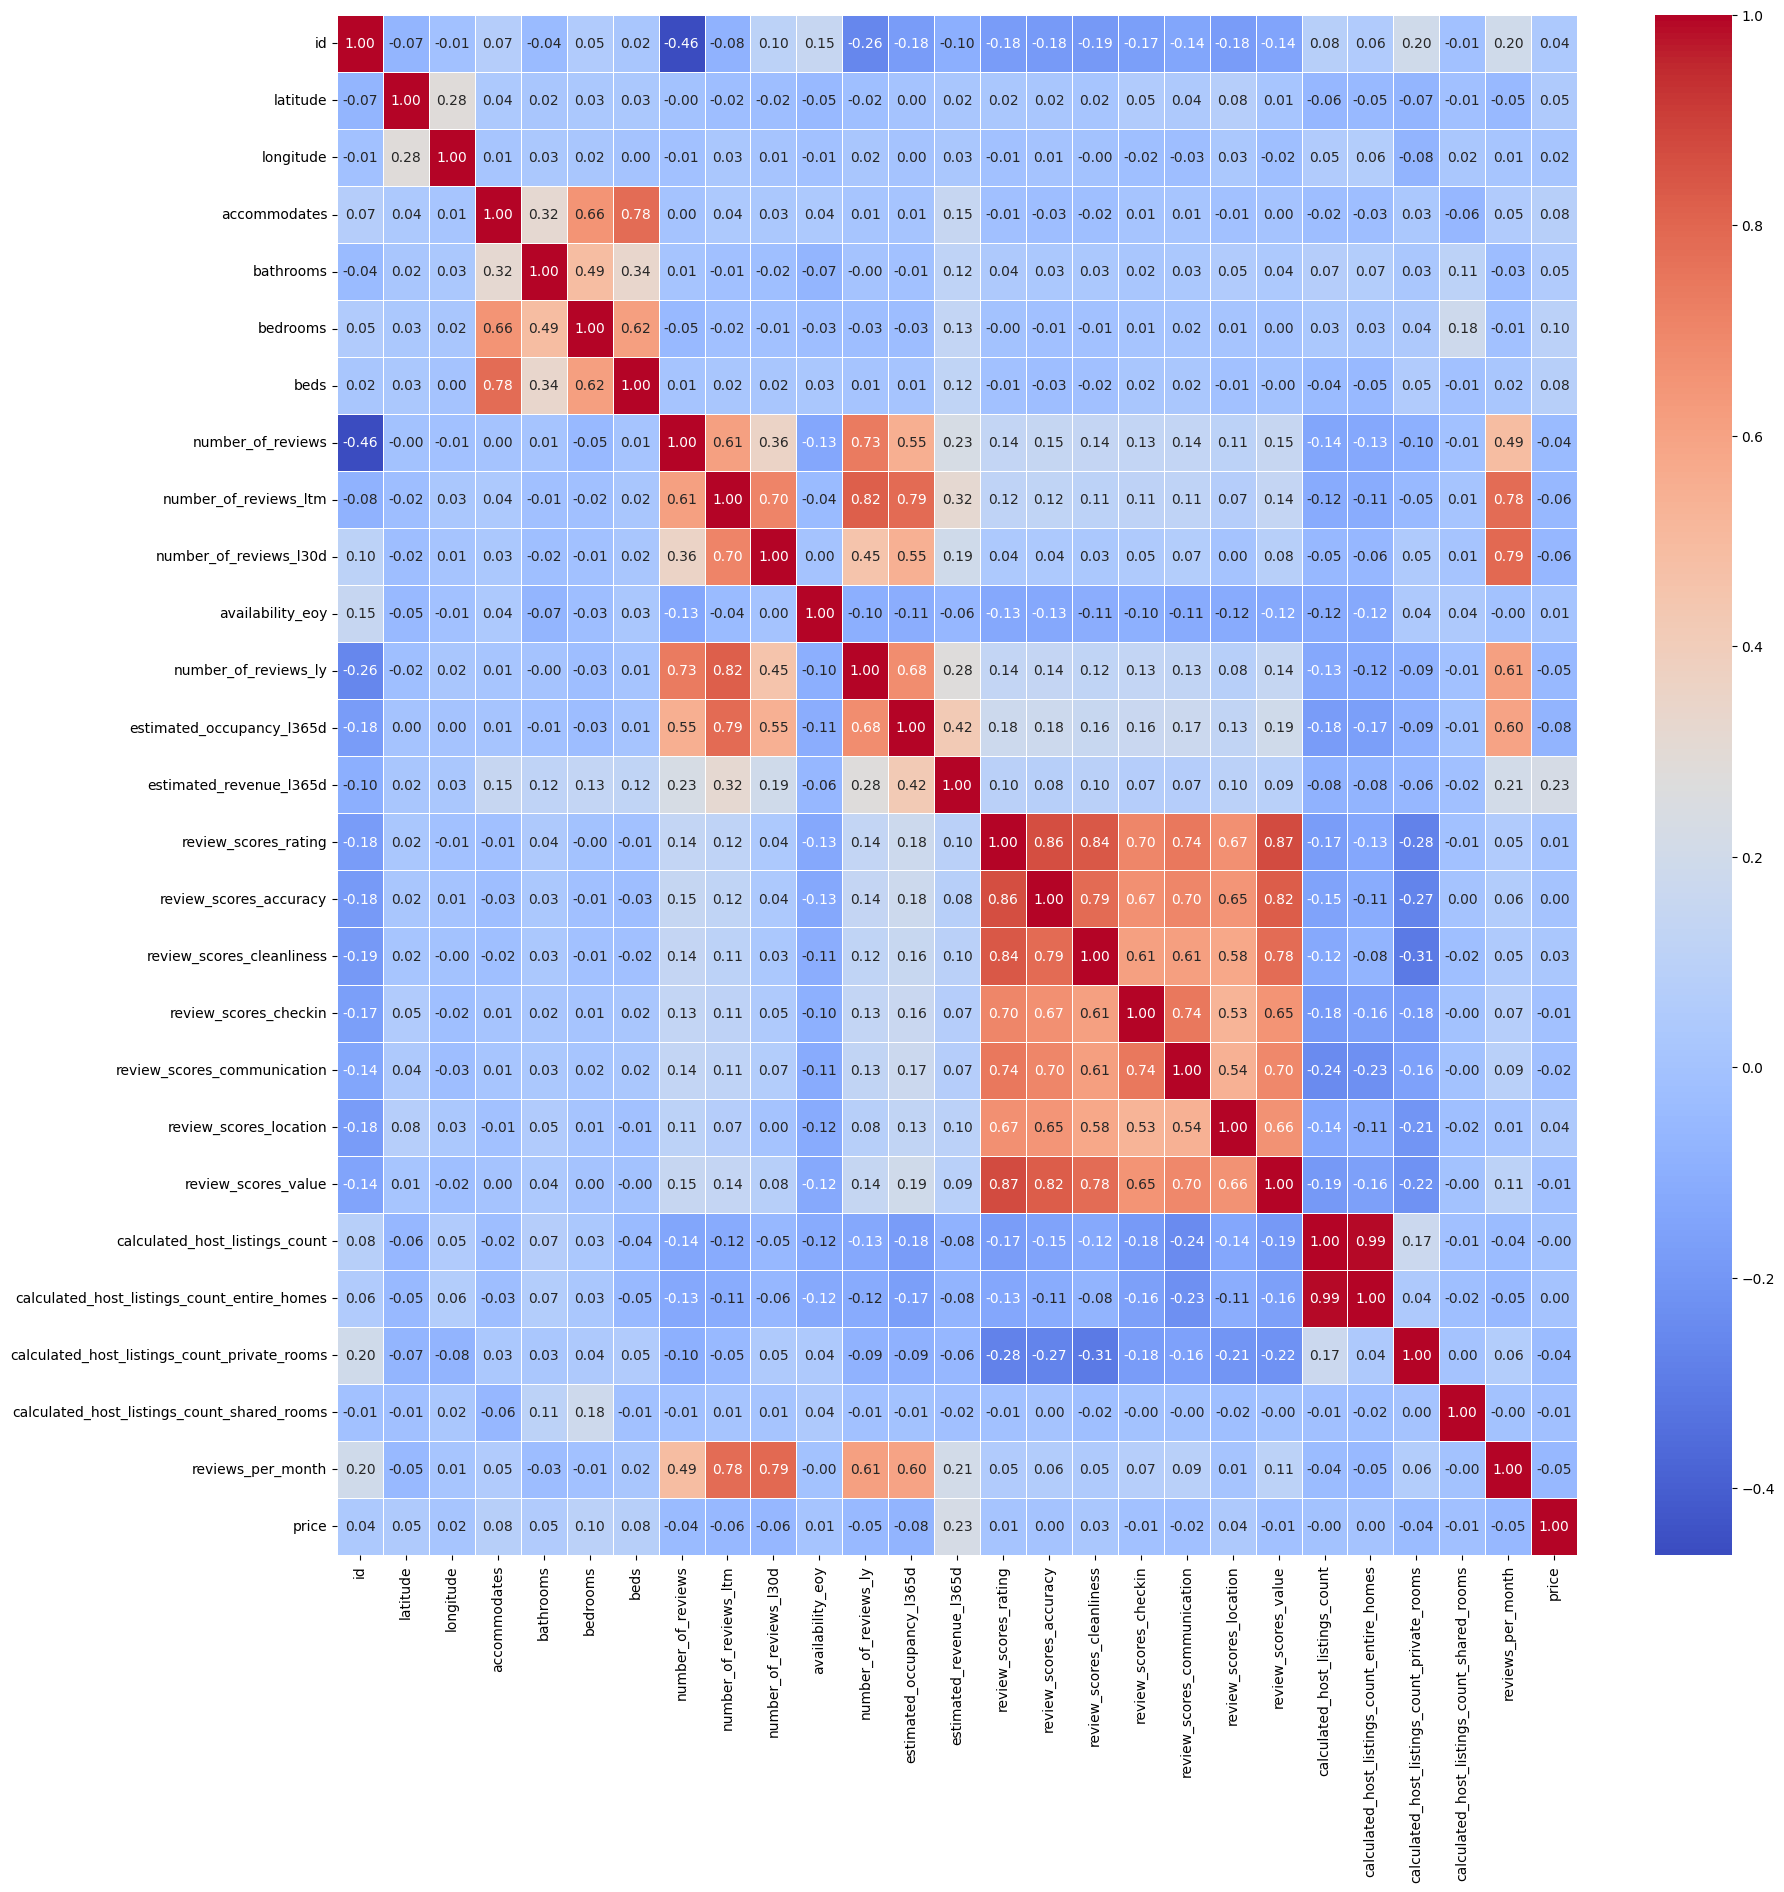

In [ ]:
import seaborn as sns

#Converts price to an integer.
listings_df['price'] = listings_df['price'].str.replace(',', '').str.replace('$', '').str.replace('.00', '').astype(int)

#Separate numeric columns
num_cols = ['id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds','number_of_reviews',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'availability_eoy',
'number_of_reviews_ly',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin'	,
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month','price',]


#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')
#sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, vmin = -1, vmax = 1) Can use to adust gradient



The review_scores columns are highly correlated, and reducing them will be important for feature selection. Number_of_reviews, host_listings_count, and accomodates should also be considered.

In [ ]:
#Removing some of the highly correlated columns
Columns_to_Drop2 = ['review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin'	,
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'number_of_reviews',
'number_of_reviews_l30d',
'number_of_reviews_ly',]

listings_df.drop(columns = Columns_to_Drop2, inplace = True)

<Axes: >

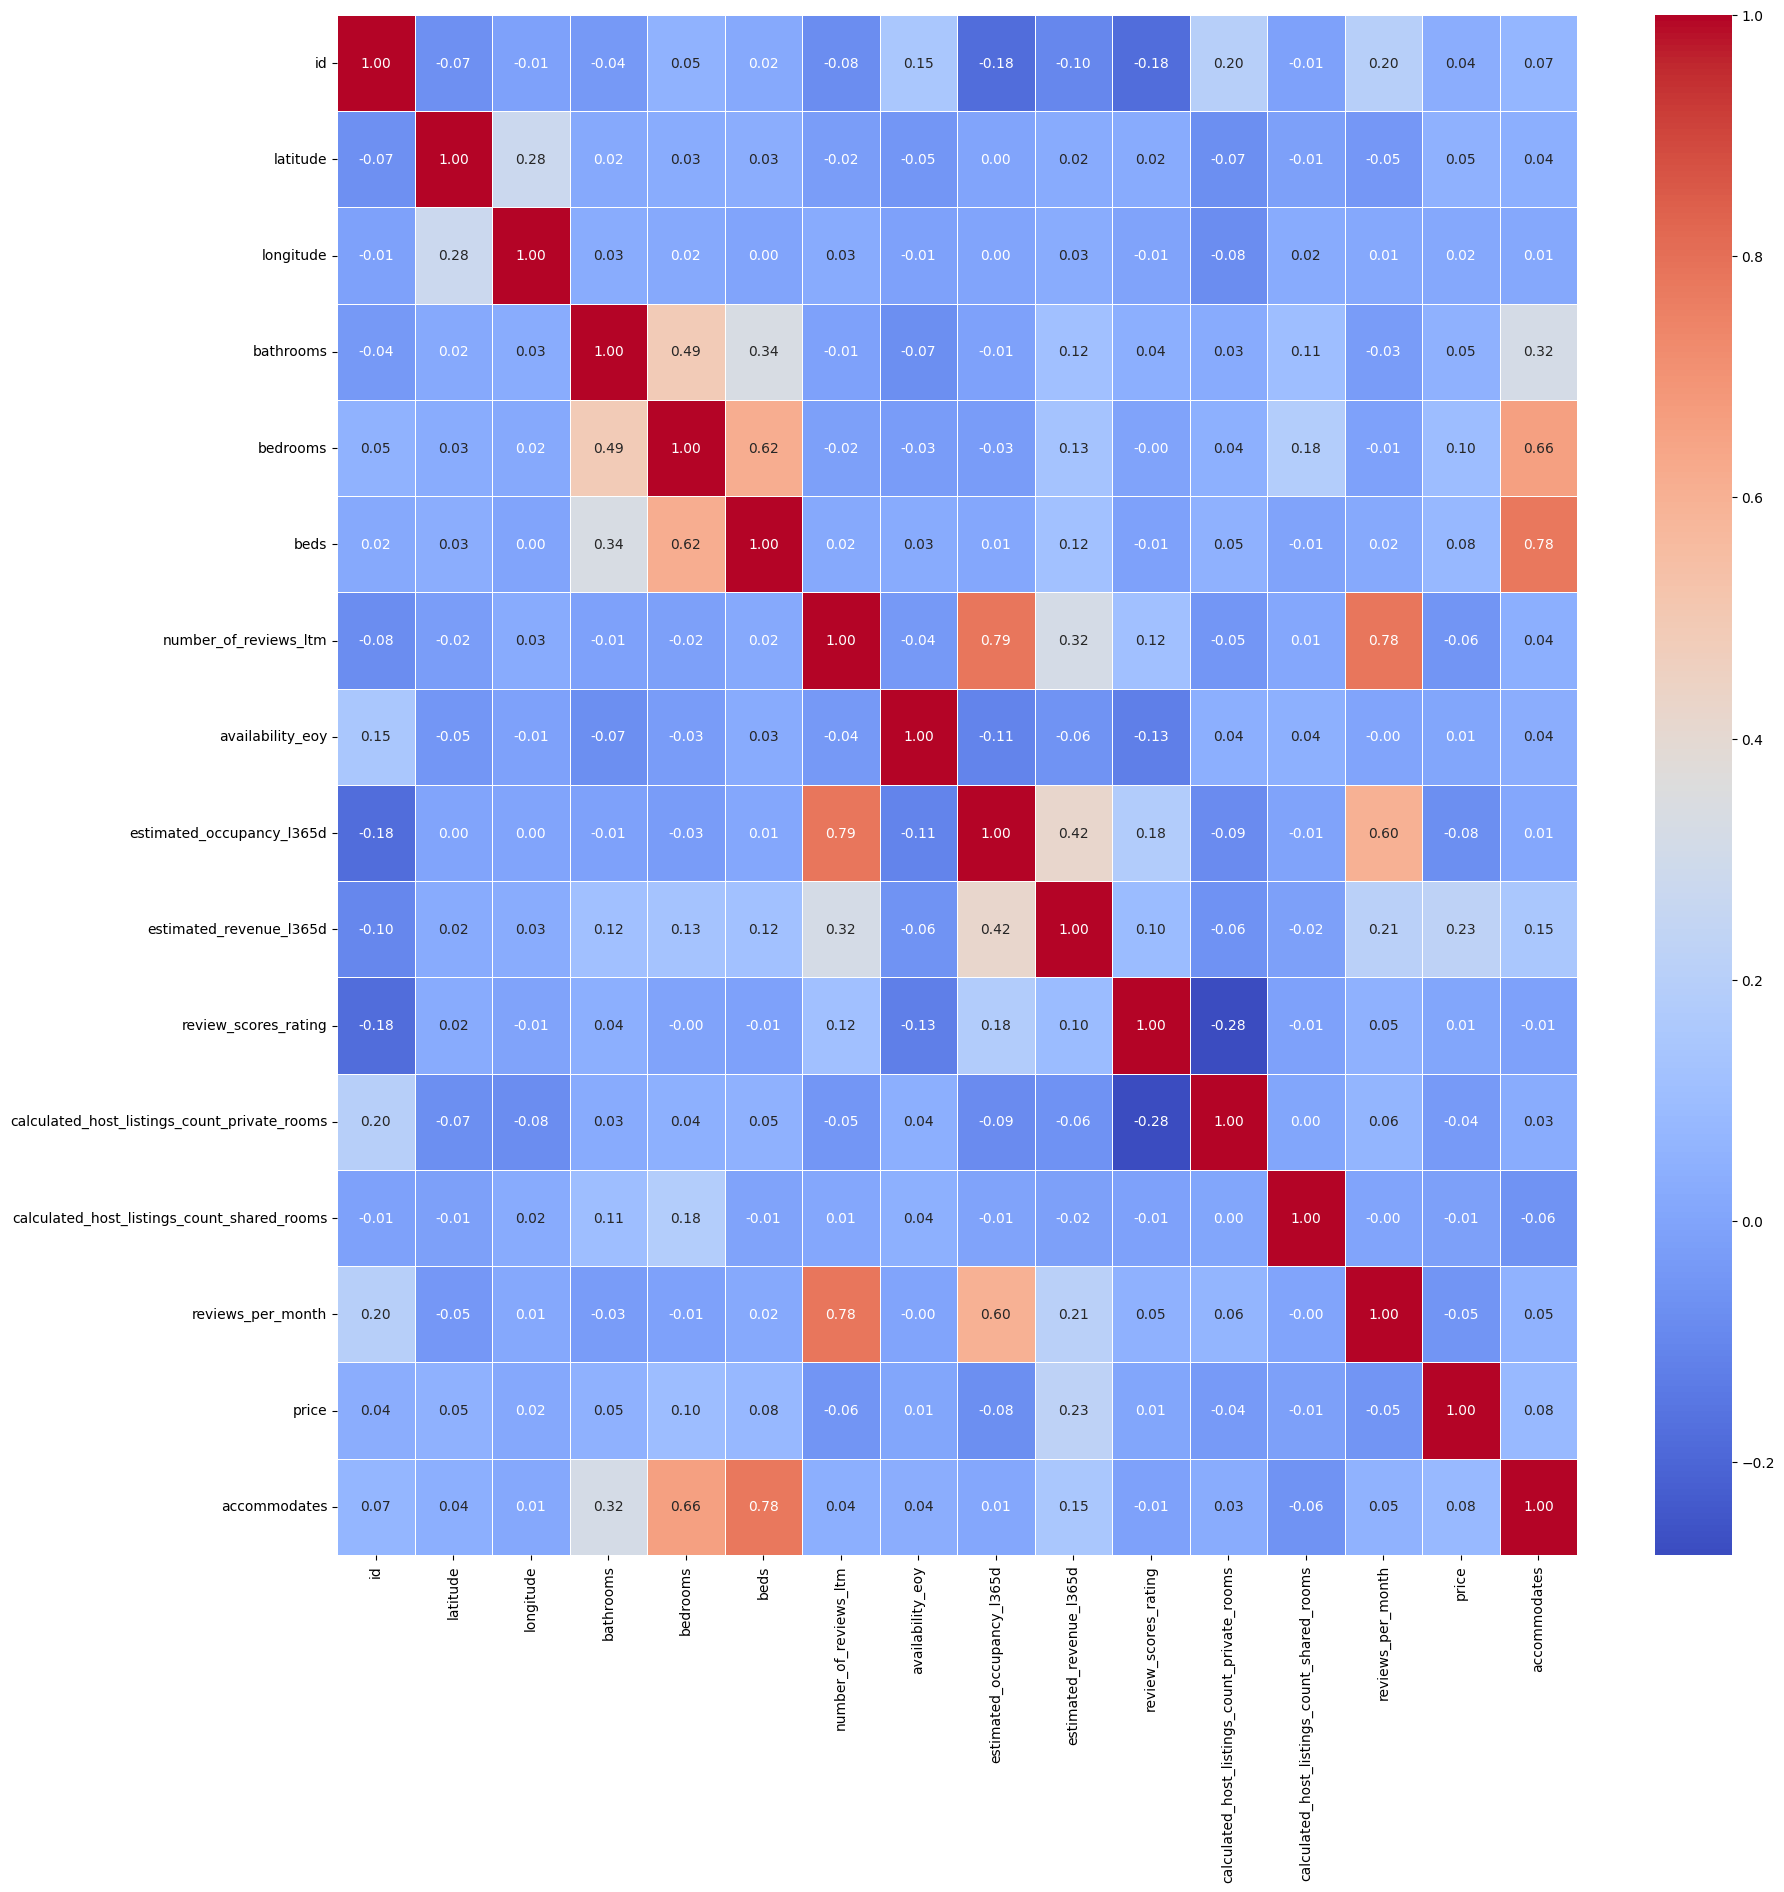

In [ ]:
#Generating a correlation heatmap with only the undropped columns.
num_cols = ['id', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'beds',
'number_of_reviews_ltm',
'availability_eoy',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month','price','accommodates']

#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')
#sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, vmin = -1, vmax = 1) Can use to adust gradient


In [ ]:
#Checking the shape
print(listings_df.shape)
print("------------")
# Checking percent of missing values for column.
missing_perc1 = listings_df.isna().sum()/len(listings_df) * 100
print(missing_perc1)

(10264, 23)
------------
id                                               0.000000
neighbourhood_cleansed                           0.000000
latitude                                         0.000000
longitude                                        0.000000
property_type                                    0.000000
room_type                                        0.000000
accommodates                                     0.000000
bathrooms                                        0.000000
bedrooms                                         0.000000
beds                                             0.000000
amenities                                        0.000000
price                                            0.000000
number_of_reviews_ltm                            0.000000
availability_eoy                                 0.000000
estimated_occupancy_l365d                        0.000000
estimated_revenue_l365d                          0.000000
first_review                                   

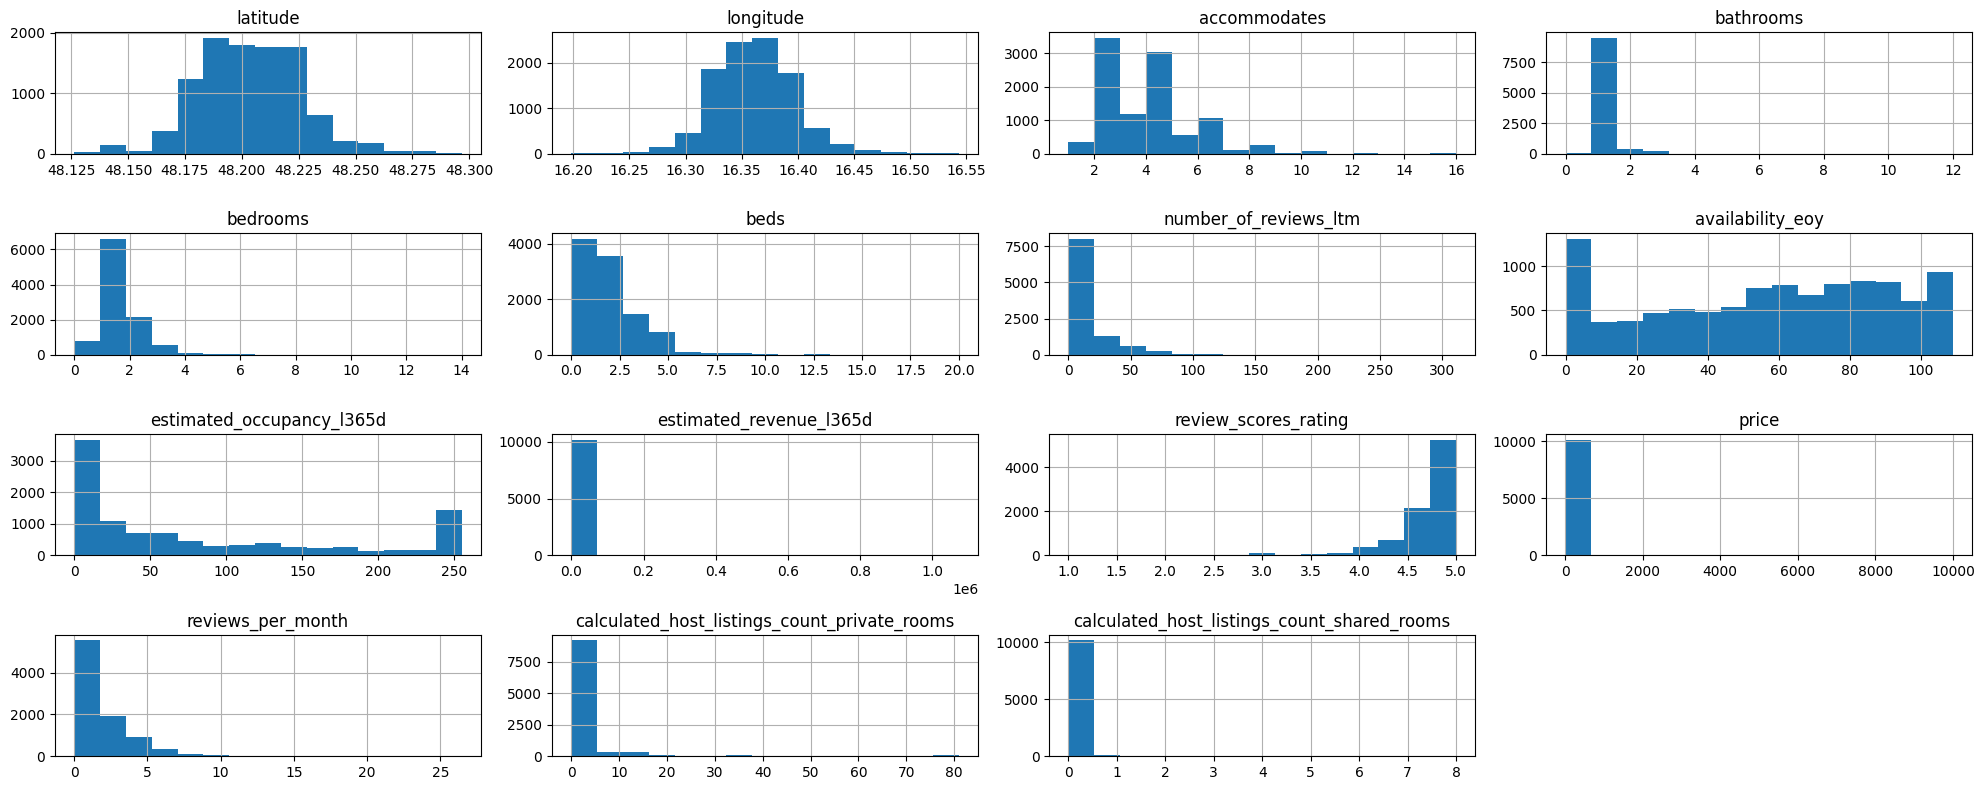

In [ ]:
#Histogram of numeric columns

#This just removes listing ID, which it isn't useful to have a histogram of.
num_cols2 = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
'number_of_reviews_ltm',
'availability_eoy',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating','price',
'reviews_per_month',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms']

listings_df[num_cols2].hist(bins=15, figsize=(20,8))
plt.tight_layout()
plt.show()

In [ ]:
listings_df[num_cols2].describe()


,latitude,longitude,accommodates,bathrooms,bedrooms,beds,number_of_reviews_ltm,availability_eoy,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,price,reviews_per_month,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
count,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,1.026400e+04,8876.000000,10264.000000,8876.000000,10264.000000,10264.000000
mean,48.203342,16.361295,3.669232,1.182970,1.313426,2.032443,13.282931,56.984509,81.530008,9.091407e+03,4.668018,155.596454,1.823310,2.652572,0.026208
std,0.023183,0.036093,1.980565,0.482863,0.884035,1.355542,20.177412,33.619262,90.585591,2.275947e+04,0.469546,523.179107,1.942133,9.934694,0.332985
min,48.126310,16.198216,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,13.000000,0.010000,0.000000,0.000000
25%,48.187703,16.336535,2.000000,1.000000,1.000000,1.000000,1.000000,30.000000,6.000000,3.540000e+02,4.590000,66.000000,0.430000,0.000000,0.000000
50%,48.202245,16.360890,4.000000,1.000000,1.000000,2.000000,5.000000,61.000000,42.000000,3.942000e+03,4.790000,93.000000,1.150000,0.000000,0.000000
75%,48.218890,16.383436,4.000000,1.000000,2.000000,2.000000,18.000000,85.000000,138.000000,1.254000e+04,4.930000,141.000000,2.630000,0.000000,0.000000
max,48.296630,16.543390,16.000000,12.000000,14.000000,20.000000,311.000000,109.000000,255.000000,1.073550e+06,5.000000,10000.000000,26.450000,81.000000,8.000000


In [ ]:
#Importing cleaned reviews
import requests
from io import StringIO

cleaned_reviews_link = "https://drive.google.com/drive/u/3/folders/1sjDP_CfyAjRmIT1dzmJonMDu3ZCgVGfv"

file_id = cleaned_reviews_link.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
cleaned_reviews_df = pd.read_csv(csv_raw)
print(cleaned_reviews_df.head())

Empty DataFrame
Columns: [<html lang="en" dir=ltr><meta charset=utf-8><meta name=viewport content="initial-scale=1,  minimum-scale=1,  width=device-width"><title>Error 404 (Not Found)!!1</title><style nonce="cy8gSrcR2moLnHy2yJAM2w">*{margin:0;padding:0}html, code{font:15px/22px arial, sans-serif}html{background:#fff;color:#222;padding:15px}body{color:#222;text-align:unset;margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px;}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}pre{white-space:pre-wrap;}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/branding/googlelogo/1x/googlelogo_color_150x54dp.png) no-repeat;margin-left:-5px}@media only screen and (min-resolution:192dpi){#logo{background:url(//www.google.com/images/branding/google

# Filtering By Date

In [ ]:
df_cleaned.head()
df_cleaned.shape

(319600, 5)

In [ ]:
#Filtering for the last 10 reviews per listing, and concatenating them

print('Pre-sort')
print(df_cleaned.nunique())



# Code from class tutorial
# Get the last 10 reviews per listing
latest_reviews = (
    df_cleaned.sort_values(['listing_id', 'date'], ascending=[True, False])
      .groupby('listing_id')
      .head(10)
)



# Concatenate all reviews into one combined text per listing CHECK THIS
listing_texts = (
  latest_reviews
   .groupby('listing_id')['comments']
   .apply(lambda x: " ".join(x.astype(str)))  # Combine all reviews into one string
   .reset_index(name='combined_reviews')
)





# Check the shape of the new DataFrame
listing_texts.shape

print('Post-sort')
print(listing_texts.nunique())

listing_texts.head()

Pre-sort
listing_id        10848
date               4908
comments         312848
language              1
review_length       474
dtype: int64
Post-sort
listing_id          10848
combined_reviews    10834
dtype: int64


,listing_id,combined_reviews
0,40625,we had a wonderful stay at this apartment the ...
1,51287,i stayed for two months in this place the inst...
2,109679,we had a nice stay the apartment was easy to f...
3,114505,ingela is super nice and thoughtful the place ...
4,169672,astrid was a wonderful host with a beautiful s...


# Merging the Reviews and Listings Data

In [ ]:
#Merging the two dataframes using the common listing ID, then checking the head and shape.
merged_df = pd.merge(listings_df, latest_reviews, left_on='id', right_on='listing_id').drop(columns=['id'])
print(merged_df.head())

print(merged_df.shape)

  neighbourhood_cleansed  latitude  longitude       property_type  \
0   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
1   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
2   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
3   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
4   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   

         room_type  accommodates  bathrooms  bedrooms  beds  \
0  Entire home/apt             6        1.0       2.0   3.0   
1  Entire home/apt             6        1.0       2.0   3.0   
2  Entire home/apt             6        1.0       2.0   3.0   
3  Entire home/apt             6        1.0       2.0   3.0   
4  Entire home/apt             6        1.0       2.0   3.0   

                                           amenities  ...  \
0  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...   
1  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...   
2  ["Smoke alarm", "Pac

In [ ]:
merged_df.isnull().sum()

,0
neighbourhood_cleansed,0
latitude,0
longitude,0
property_type,0
room_type,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
amenities,0


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58500 entries, 0 to 58499
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   neighbourhood_cleansed                        58500 non-null  object 
 1   latitude                                      58500 non-null  float64
 2   longitude                                     58500 non-null  float64
 3   property_type                                 58500 non-null  object 
 4   room_type                                     58500 non-null  object 
 5   accommodates                                  58500 non-null  int64  
 6   bathrooms                                     58500 non-null  float64
 7   bedrooms                                      58500 non-null  float64
 8   beds                                          58500 non-null  float64
 9   amenities                                     58500 non-null 

Text Preprocessing Raw reviews often contain punctuation, capitalization, numbers, and stopwords (common words like the, is, at). Before applying NLP techniques such as Bag-of-Words or TF-IDF, we need to clean and standardize the text.

In this step, we will:

Convert text to lowercase Remove punctuation and numbers Remove common stopwords (Optional) Apply stemming or lemmatization — reducing words to their root form (running → run)

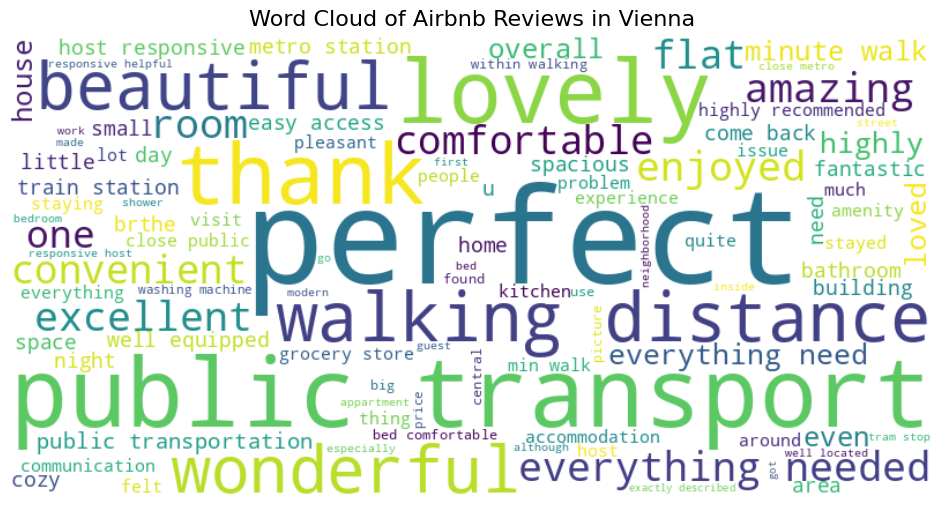

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure 'cleaned_comments' column exists. If not, re-create it.
if "cleaned_comments" not in merged_df.columns:
    # Download stopwords & wordnet if not already
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)

    stop_words = set(stopwords.words("english"))
    custom_stopwords = {"airbnb", "vienna", "recommend", "apartment", "good","great","nice", "really", "stay", "time","place","city","definitely", "absolutely", "clean", "location"}
    stop_words = stop_words.union(custom_stopwords)
    lemmatizer = WordNetLemmatizer()

    def preprocess_text(text):
        # Lowercase
        text = text.lower()
        # Remove punctuation and numbers
        text = re.sub(r'[^a-z\s]', '', text)
        # Tokenize
        tokens = text.split()
        # Remove stopwords and lemmatize
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        tokens=list(dict.fromkeys(tokens))
        return " ".join(tokens)

    # Apply preprocessing
    merged_df["cleaned_comments"] = merged_df["comments"].apply(preprocess_text)

# Combine all cleaned reviews into one big text
all_text = " ".join(merged_df["cleaned_comments"])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      max_words=100, colormap="viridis").generate(all_text)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Airbnb Reviews in Vienna", fontsize=16)
plt.show()

Bag-of-Words (Word Counts) The Bag-of-Words model represents text by counting how many times each word appears.

It ignores word order, grammar, and context. Each document becomes a vector of word frequencies. While simple, it often works surprisingly well for tasks like sentiment classification or topic clustering. We will use CountVectorizer from scikit-learn to transform our Airbnb reviews into a document-term matrix.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize vectorizer (limit vocab size for demo)
vectorizer = CountVectorizer(max_features=20, stop_words='english')

# Fit and transform cleaned reviews
bow_matrix = vectorizer.fit_transform(merged_df['cleaned_comments'])

# Convert to DataFrame for readability
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print("Shape of BoW matrix:", bow_df.shape)
bow_df.head(10)

Shape of BoW matrix: (58500, 20)


,center,close,comfortable,easy,helpful,highly,host,kitchen,minute,need,perfect,public,quiet,responsive,restaurant,room,spacious,station,transport,walk
0,0,0,1,1,0,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
8,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,1,0


TF-IDF (Term Frequency–Inverse Document Frequency) Bag-of-Words gives us raw counts of words, but it does not distinguish between common words (like room, place, stay) and more meaningful words.

TF-IDF improves on this by weighting words based on two factors:

Term Frequency (TF): How often a word appears in a single document. Inverse Document Frequency (IDF): How rare the word is across the entire collection of documents. Why it matters Words that are frequent in a single review but rare across all reviews (e.g., fireplace, mountain, cozy) receive higher importance. Very common words that appear in nearly every review (e.g., room, good, stay) are downweighted. Key Takeaway TF-IDF highlights the most distinctive words in reviews, giving us a more meaningful text representation for analysis and modeling.

We will now apply TF-IDF to our Airbnb sample reviews and inspect the top weighted words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=1000, max_df=0.85, min_df=15, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(merged_df['cleaned_comments'])

# Convert to DataFrame for inspection
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Show top rows
print("TF-IDF matrix (first 5 rows):")
display(tfidf_df.head())

TF-IDF matrix (first 5 rows):


,able,ac,access,access public,accessible,accessible public,accommodating,accommodation,accomodation,accurate,...,wont,work,worked,working,worth,worth price,wouldnt,year,youll,youre
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Words like "comfortable", "great", "host", "location", "station", "city", "recommend" tend to have higher IF-IDF scores in specific listings. This indicates these words are particulary important or distinctive for those reviews, even if they may not appear frequently across all listings.

##N-grams
N-grams capture phrases and context, making them more informative for understanding text compared to isolated words. They are especially useful in sentiment analysis, topic modeling, and search engines where meaning depends on word combinations.

In the next step, we will generate bigrams and trigrams from the Vienna Airbnb reviews and explore the most common ones.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Use bigrams and trigrams (n=2 and n=3)
ngram_vectorizer = CountVectorizer(ngram_range=(2,3), stop_words='english', max_features=30)

# Fit and transform on the cleaned reviews
X_ngrams = ngram_vectorizer.fit_transform(merged_df['cleaned_comments'])

# Convert to dataframe
ngrams_df = pd.DataFrame(X_ngrams.toarray(), columns=ngram_vectorizer.get_feature_names_out())

# Get the top n-grams by summing across all documents
top_ngrams = ngrams_df.sum().sort_values(ascending=False).head(20)

print("Top 20 most frequent bigrams and trigrams:")
print(top_ngrams)

Top 20 most frequent bigrams and trigrams:
public transport         3514
walking distance         2454
minute walk              1757
public transportation    1683
train station            1526
easy access              1453
metro station            1403
host responsive          1375
highly recommended       1232
grocery store            1226
close public             1082
min walk                  934
bed comfortable           885
close metro               844
washing machine           840
responsive helpful        833
responsive host           805
like home                 757
tram stop                 742
exactly described         739
dtype: int64


In [ ]:
# Define functions to create plots

import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

# Function to plot the top words for each topic
def plot_top_words(model, feature_names, n_top_words=10, title='Top words per topic'):
    fig, axes = plt.subplots(1, model.n_components, figsize=(15, 5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx+1}', fontdict={'fontsize': 10})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=10)
    plt.suptitle(title, fontsize=12)
    plt.subplots_adjust(top=0.85, wspace=0.3)
    plt.show()


# Function to generate word clouds for each topic
def plot_word_clouds(model, feature_names, n_top_words=30):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = {feature_names[i]: topic[i] for i in top_features_ind}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_features)
        plt.figure()
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {topic_idx+1} Word Cloud', fontsize=16)
        plt.show()

##Topic modeling
Latent Dirichlet Allocation (LDA) Treats each document as a mixture of topics. Each topic is represented as a distribution of words. Helps discover interpretable themes in text.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

In [ ]:
#LDA
# Set the number of topics
n_topics = 4

# Create and fit the LDA model
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_model.fit(bow_matrix)
#lda_model.fit(X_tfidf)

# Extract the top words from each topic
terms = vectorizer.get_feature_names_out()
lda_topics = {}

for index, topic in enumerate(lda_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lda_topics[f"Topic {index+1}"] = top_words

# Print the LDA topics
print("LDA Topics:")
for topic, words in lda_topics.items():
    print(f"{topic}: {', '.join(words)}")

LDA Topics:
Topic 1: public, transport, quiet, spacious, easy, comfortable, kitchen, helpful, center, room
Topic 2: host, perfect, responsive, helpful, room, easy, kitchen, spacious, center, station
Topic 3: close, highly, comfortable, center, station, room, spacious, host, quiet, easy
Topic 4: walk, need, easy, restaurant, minute, station, quiet, comfortable, kitchen, spacious


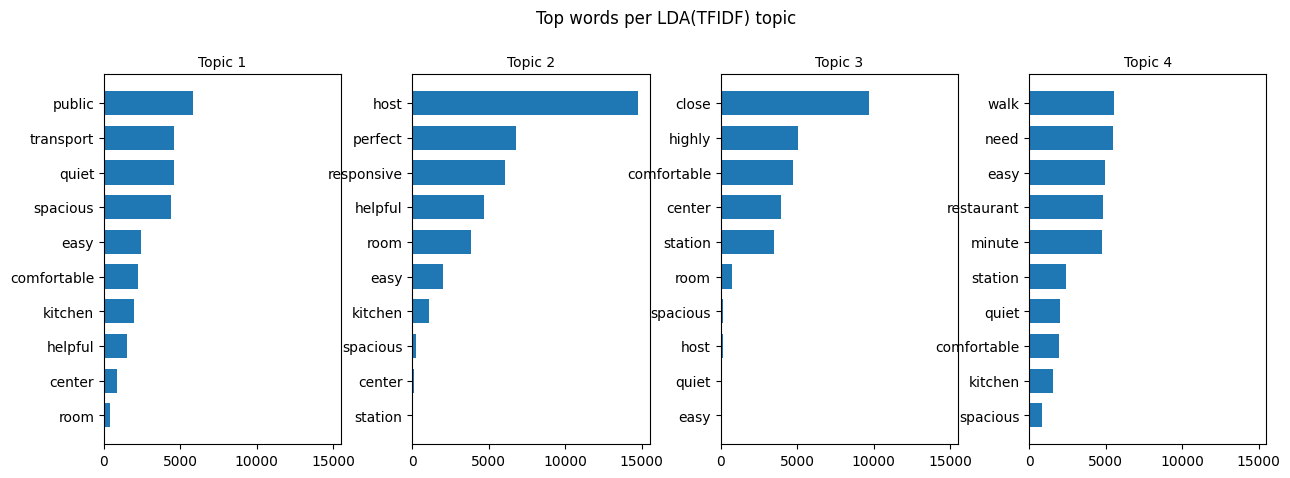

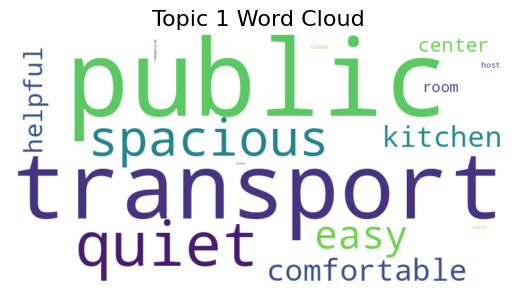

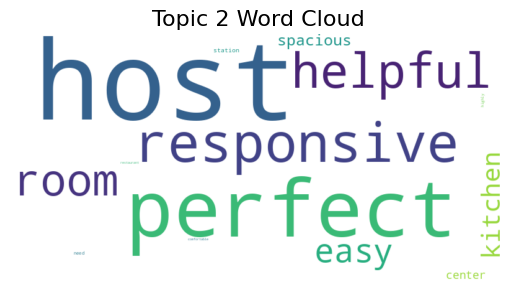

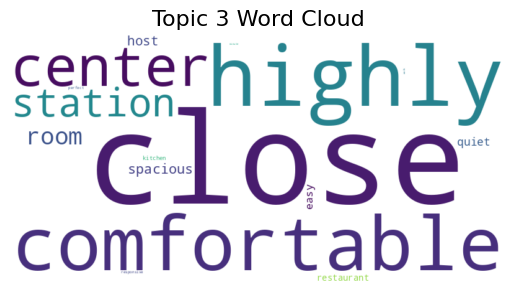

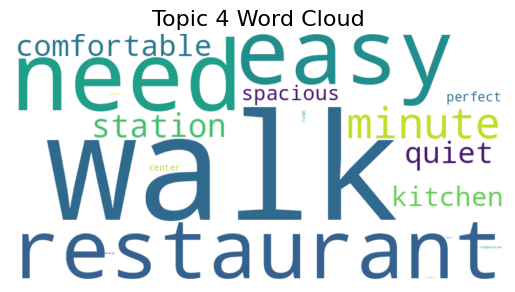

In [ ]:
plot_top_words(lda_model, terms, n_top_words=10, title='Top words per LDA(TFIDF) topic')
plot_word_clouds(lda_model, terms)

2) Non-negative Matrix Factorization (NMF)
Decomposes the TF-IDF matrix into smaller components. Each component (topic) is described by the top keywords. Works well for short and interpretable topics.

In [ ]:
# Create and fit the NMF model
nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_model.fit(X_tfidf)

# Extract the top words from each topic
nmf_topics = {}
terms=tfidf.get_feature_names_out()
for index, topic in enumerate(nmf_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    nmf_topics[f"Topic {index+1}"] = top_words

# Print the NMF topics
print("NMF Topics:")
for topic, words in nmf_topics.items():
    print(f"{topic}: {', '.join(words)}")

NMF Topics:
Topic 1: comfortable, station, quiet, easy, close, spacious, walk, need, metro, minute
Topic 2: host, responsive, helpful, friendly, host responsive, responsive host, highly, amazing, friendly host, helpful host
Topic 3: perfect, thank, thanks, amazing, highly, family, perfect host, beautiful, loved, perfect close
Topic 4: public, transport, public transport, close, close public, easy, transportation, public transportation, access, easy access


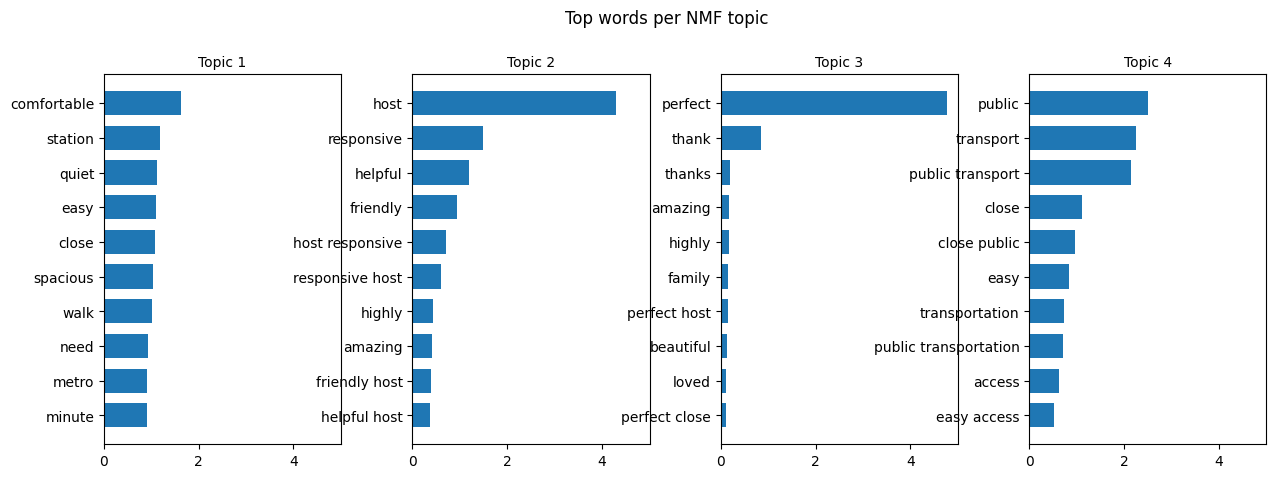

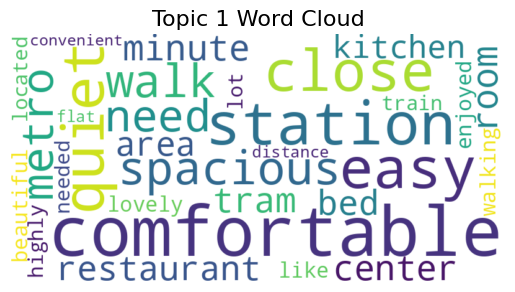

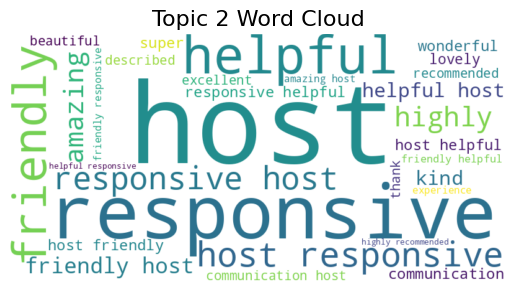

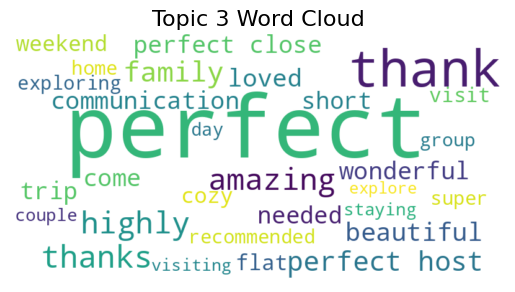

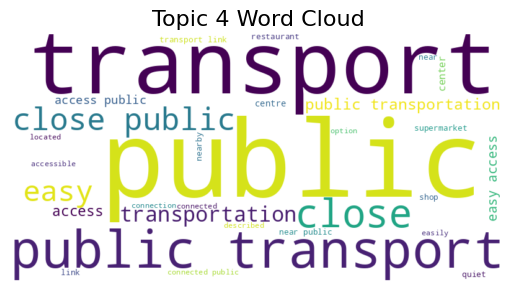

In [ ]:
# NMF topic plots

plot_top_words(nmf_model, terms, n_top_words=10, title='Top words per NMF topic')
plot_word_clouds(nmf_model, terms)

##Latent Semantic Analysis (LSA)

Uses Singular Value Decomposition (SVD) to identify underlying structures in

Captures broader word associations but can be harder to interpret.

In [ ]:
#Fit the LSA model
lsa_model = TruncatedSVD(n_components=n_topics, random_state=42)
lsa_model.fit(X_tfidf)


# Extract the top words for each topic
terms = tfidf.get_feature_names_out()
lsa_topics = {}

for index, topic in enumerate(lsa_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lsa_topics[f"Topic {index+1}"] = top_words

# Print the LSA topics
print("LSA Topics:")
for topic, words in lsa_topics.items():
    print(f"{topic}: {', '.join(words)}")

LSA Topics:
Topic 1: host, close, comfortable, easy, perfect, responsive, helpful, public, quiet, spacious
Topic 2: host, perfect, responsive, helpful, friendly, thank, host responsive, responsive host, amazing, highly
Topic 3: perfect, thank, family, thanks, loved, short, perfect host, perfect close, beautiful, trip
Topic 4: public, transport, public transport, close public, perfect, close, public transportation, transportation, host, easy


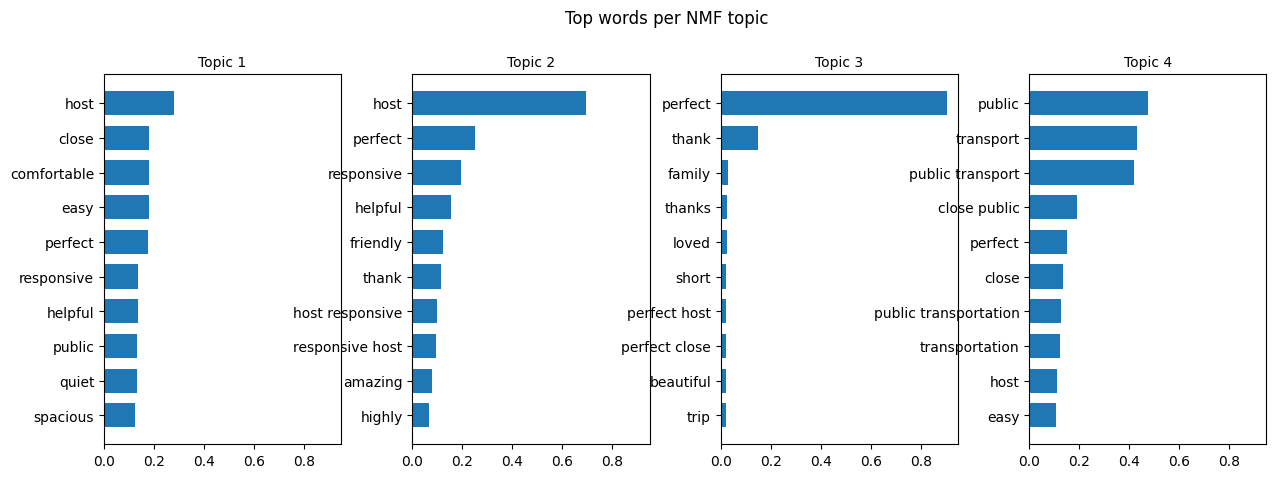

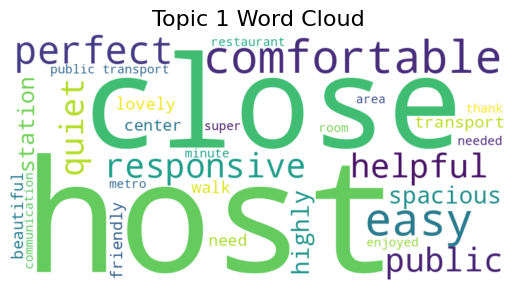

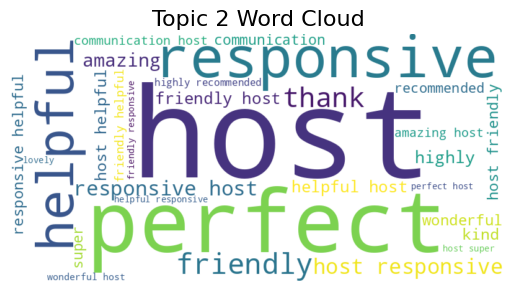

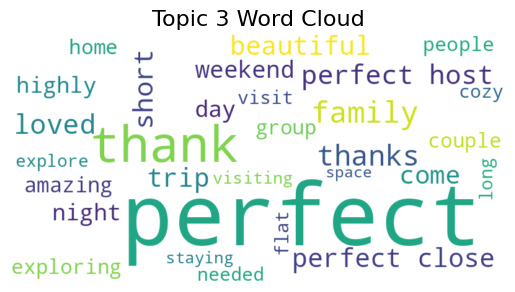

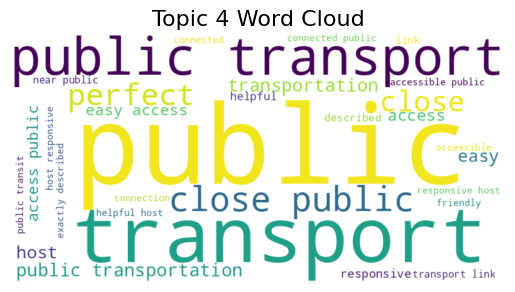

In [ ]:
# LSA topic plots

plot_top_words(lsa_model, terms, n_top_words=10, title='Top words per NMF topic')
plot_word_clouds(lsa_model, terms)

In [ ]:
#Let's check the topic distance

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Function to plot topic distances using PCA
def plot_topic_distance_pca(model, title='Topic Distance (PCA)'):
    # Get the topic-word matrix (components_) from the model
    topic_word_matrix = model.components_

    # Apply PCA to reduce the topic-word matrix to 2 dimensions
    pca = PCA(n_components=2)
    topic_pca = pca.fit_transform(topic_word_matrix)

    # Plot the topics in 2D space
    plt.figure(figsize=(8, 6))
    plt.scatter(topic_pca[:, 0], topic_pca[:, 1], c='blue', edgecolor='k', s=100)

    # Annotate the topics with text labels
    for i in range(len(topic_pca)):
        plt.text(topic_pca[i, 0], topic_pca[i, 1], f'Topic {i+1}', fontsize=12)

    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

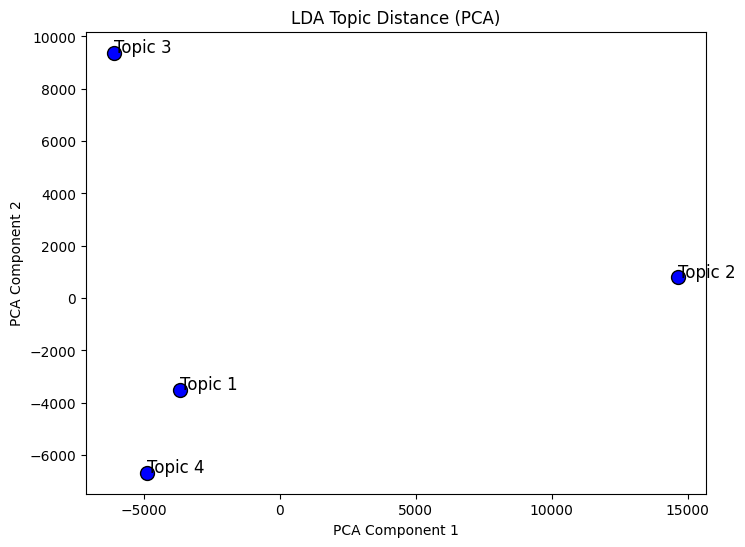

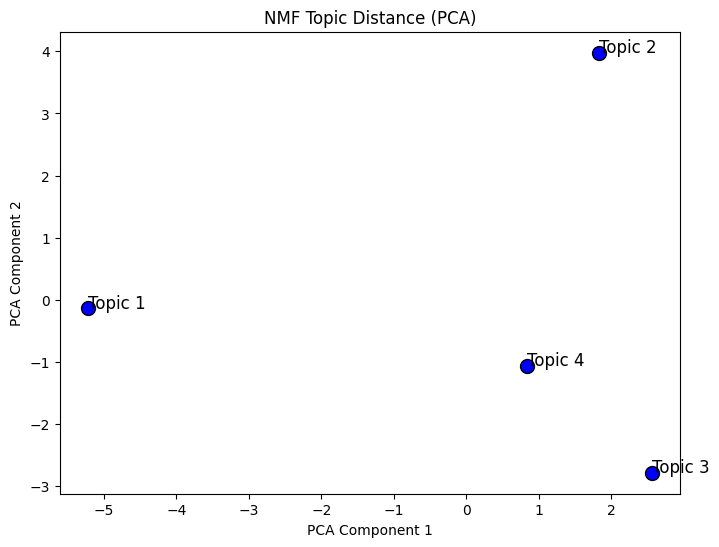

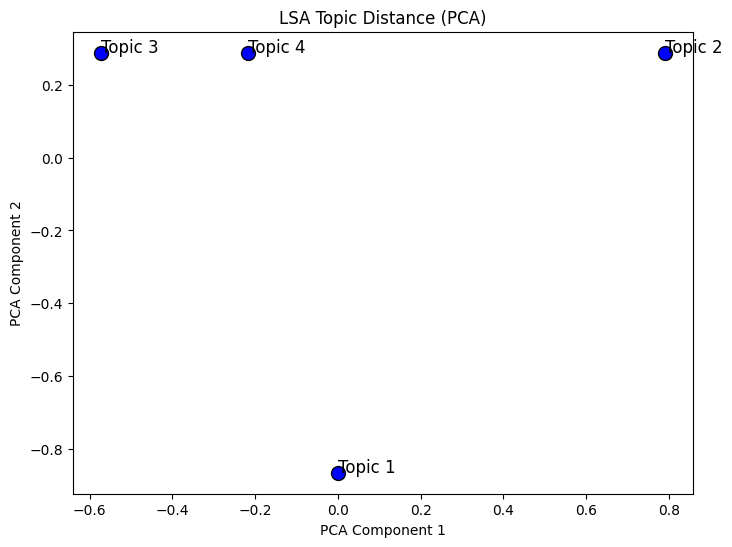

In [ ]:
# compare topic distance of all models

# LDA
plot_topic_distance_pca(lda_model, title='LDA Topic Distance (PCA)')
# NMF
plot_topic_distance_pca(nmf_model, title='NMF Topic Distance (PCA)')
# LSA
plot_topic_distance_pca(lsa_model, title='LSA Topic Distance (PCA)')


NMF produced more distinct and interpretable topics, with clearer separation between location, host quality and comfort-related attributes. Topic 1 is Location&Comfort, Topic 2 is Host Quality & Service, Topic 3 is Customer Satisfaction, Topic 4 is Transport Accessibility

In [ ]:
#Assign topic probabilities:
topic_model=nmf_model.transform(X_tfidf)

In [ ]:
reviews_df_topic=pd.DataFrame(topic_model)
reviews_df_topic['listing_id']=merged_df['listing_id']
reviews_df_topic.head()

,0,1,2,3,listing_id
0,0.030021,0.022148,0.022372,0.000272,40625
1,0.010909,0.000000,0.003123,0.000000,40625
2,0.008651,0.057888,0.009085,0.000000,40625
3,0.013608,0.003001,0.041260,0.000000,40625
4,0.021764,0.000000,0.000000,0.000412,40625


In [ ]:
#aggregation
listing_topics=reviews_df_topic.groupby('listing_id').mean()

listing_topics.columns=["topic_loc_and_comf",
                        "topic_host",
                        "topic_sentiment",
                        "topic_transport"
                        ]
listing_topics.head()

,topic_loc_and_comf,topic_host,topic_sentiment,topic_transport
listing_id,,,,
40625,0.014901,0.014038,0.012786,0.008264
51287,0.024217,0.015153,0.002452,0.007612
109679,0.013598,0.015455,0.004697,0.009132
114505,0.017719,0.014697,0.008250,0.009267
169672,0.016889,0.020366,0.006903,0.009101


In [ ]:
topic_sums=listing_topics.sum()
print(topic_sums)

topic_loc_and_comf    141.788187
topic_host             90.743788
topic_sentiment        55.109652
topic_transport        64.639945
dtype: float64


In [ ]:
#Normilizing topic shares:
topic_distribution=topic_sums/topic_sums.sum()
print(topic_distribution)

topic_loc_and_comf    0.402485
topic_host            0.257589
topic_sentiment       0.156436
topic_transport       0.183489
dtype: float64


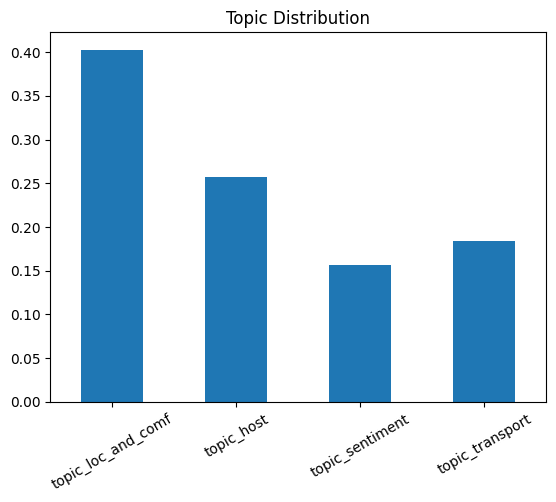

In [ ]:
topic_distribution.plot(kind='bar', title="Topic Distribution")
plt.xticks(rotation=30)
plt.show()

##Using pipeline for sentiment

In [ ]:
# import torch
# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# tokenizer = DistilBertTokenizer.from_pretrained(
#     "distilbert-base-uncased-finetuned-sst-2-english"
# )
# model = DistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased-finetuned-sst-2-english"
# )

# model.eval()

In [ ]:
# def get_sentiment_batch(texts, batch_size=32):
#     results = []

#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i+batch_size]

#         inputs = tokenizer(
#             list(batch),
#             return_tensors="pt",
#             truncation=True,
#             padding=True,
#             max_length=512
#         )

#         with torch.no_grad():
#             logits = model(**inputs).logits

#         probs = torch.nn.functional.softmax(logits, dim=1)
#         scores = (probs[:,1] - probs[:,0]).tolist()

#         results.extend(scores)
#     return results

In [ ]:
# texts=merged_df["cleaned_comments"].fillna("").tolist()
# merged_df["sentiment"] = get_sentiment_batch(texts, batch_size=16)

In [ ]:
# listing_sentiment = (
#     merged_df.groupby("listing_id", as_index=False)["sentiment"]
#     .mean()
#     .rename(columns={"sentiment": "avg_sentiment"})
# )

In [ ]:
# listing_sentiment.head()

In [ ]:
# #saving cleaned dataset
# listing_sentiment.to_csv('listing_sentiment.csv', index=False)
# files.download('listing_sentiment.csv')

In [ ]:
#Importing listing sentiment
import requests
from io import StringIO
import gdown
import pandas as pd

listing_sentiment_link = "https://drive.google.com/file/d/1rwSbtSDqKWiTj-SiK0GIfeC53dsklgAu/view?usp=drive_link"

# Extract file ID from the link
file_id = listing_sentiment_link.split('/')[-2]

# Construct the direct download URL for gdown
url = 'https://drive.google.com/uc?export=download&id=' + file_id

# Use gdown to download the file directly
gdown.download(url, 'listing_sentiment.csv', quiet=False)

# Load the downloaded CSV into a DataFrame
listing_sentiment_df = pd.read_csv('listing_sentiment.csv')
print(listing_sentiment_df.head())

Downloading...
From: https://drive.google.com/uc?export=download&id=1rwSbtSDqKWiTj-SiK0GIfeC53dsklgAu
To: /content/listing_sentiment.csv
100%|██████████| 283k/283k [00:00<00:00, 5.20MB/s]

   listing_id  avg_sentiment
0       40625       0.482805
1       51287       0.598834
2      109679       0.497315
3      114505       0.436749
4      169672       0.903126


In [ ]:
listing_sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8139 entries, 0 to 8138
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     8139 non-null   int64  
 1   avg_sentiment  8139 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 127.3 KB


In [ ]:
merged_df = pd.merge(merged_df, listing_sentiment_df, on='listing_id')
print(merged_df.head())

  neighbourhood_cleansed  latitude  longitude       property_type  \
0   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
1   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
2   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
3   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
4   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   

         room_type  accommodates  bathrooms  bedrooms  beds  \
0  Entire home/apt             6        1.0       2.0   3.0   
1  Entire home/apt             6        1.0       2.0   3.0   
2  Entire home/apt             6        1.0       2.0   3.0   
3  Entire home/apt             6        1.0       2.0   3.0   
4  Entire home/apt             6        1.0       2.0   3.0   

                                           amenities  ...  \
0  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...   
1  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...   
2  ["Smoke alarm", "Pac

In [ ]:
merged_df = pd.merge(merged_df, listing_topics, on='listing_id')
print(merged_df.head())

  neighbourhood_cleansed  latitude  longitude       property_type  \
0   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
1   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
2   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
3   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   
4   Rudolfsheim-Fnfhaus  48.18434   16.32701  Entire rental unit   

         room_type  accommodates  bathrooms  bedrooms  beds  \
0  Entire home/apt             6        1.0       2.0   3.0   
1  Entire home/apt             6        1.0       2.0   3.0   
2  Entire home/apt             6        1.0       2.0   3.0   
3  Entire home/apt             6        1.0       2.0   3.0   
4  Entire home/apt             6        1.0       2.0   3.0   

                                           amenities  ...        date  \
0  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...  2025-08-20   
1  ["Smoke alarm", "Pack \u2019n play/Travel crib...  ...  2

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58500 entries, 0 to 58499
Data columns (total 33 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   neighbourhood_cleansed                        58500 non-null  object 
 1   latitude                                      58500 non-null  float64
 2   longitude                                     58500 non-null  float64
 3   property_type                                 58500 non-null  object 
 4   room_type                                     58500 non-null  object 
 5   accommodates                                  58500 non-null  int64  
 6   bathrooms                                     58500 non-null  float64
 7   bedrooms                                      58500 non-null  float64
 8   beds                                          58500 non-null  float64
 9   amenities                                     58500 non-null 

<Axes: >

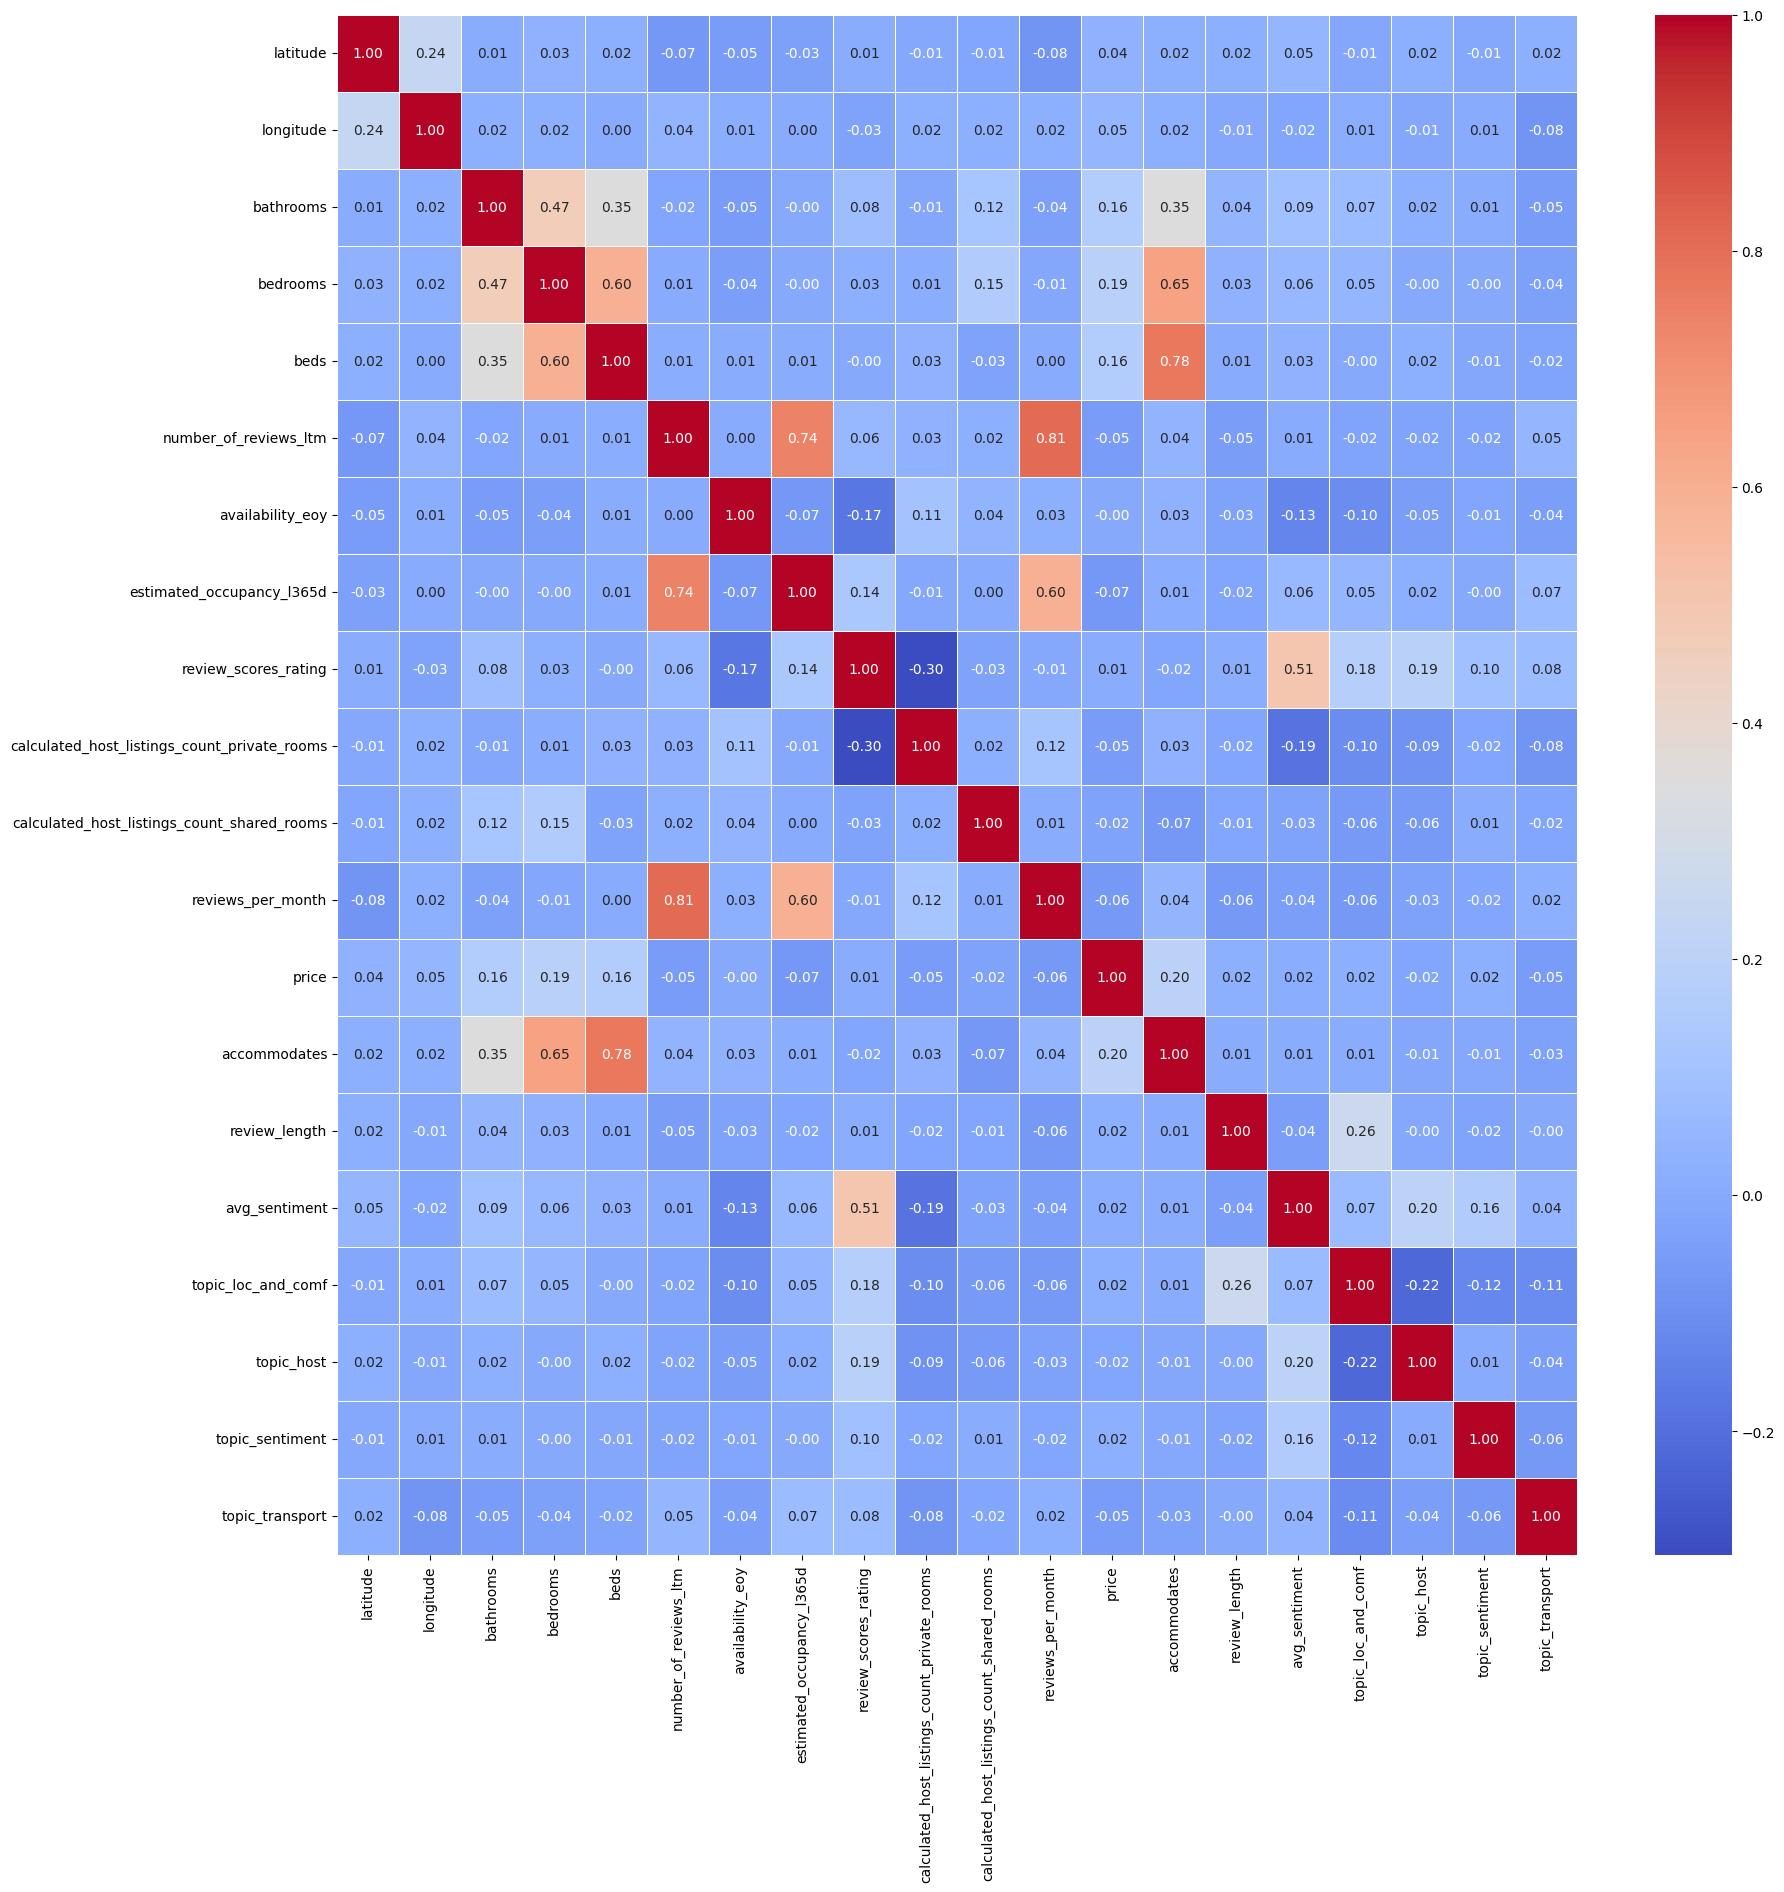

In [ ]:
#Generating a correlation heatmap with the undropped columns AND SENTIMENT
num_cols = ['latitude', 'longitude', 'bathrooms', 'bedrooms', 'beds',
'number_of_reviews_ltm',
'availability_eoy',
'estimated_occupancy_l365d',
'review_scores_rating',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month','price','accommodates',
'review_length','avg_sentiment',
"topic_loc_and_comf", "topic_host",
"topic_sentiment","topic_transport"]

#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(merged_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')
#sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, vmin = -1, vmax = 1) Can use to adust gradient

From the correlation heatmap, review length doesn't appear to have any even slightly strong correlations.
However, avg_sentiment has a 0.51 correlation with review_scores_rating, which would be expected as a higher score would come from a more positive sentiment.
#
Additionally, there are two weak, but present negative correlations with availability and the host's calculated number of private listings. A place perceived negatively may get more customers and thus be perceived more negatively, but it's interesting that this appears for the number of private rooms. This shows up slightly more strongly (-0.3) with the reveiw scores rating. **One explanation may be that with more listings, the host gives less attention and care to each, or is less able to communicate effectively with the guests.**


# EDA - Merged Dataset

In [ ]:
merged_df.shape

(58500, 33)

In [ ]:
merged_df.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'amenities', 'price', 'number_of_reviews_ltm', 'availability_eoy',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review',
       'last_review', 'review_scores_rating', 'instant_bookable',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'listing_id', 'date', 'comments', 'language', 'review_length',
       'cleaned_comments', 'avg_sentiment', 'topic_loc_and_comf', 'topic_host',
       'topic_sentiment', 'topic_transport'],
      dtype='object')

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58500 entries, 0 to 58499
Data columns (total 33 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   neighbourhood_cleansed                        58500 non-null  object 
 1   latitude                                      58500 non-null  float64
 2   longitude                                     58500 non-null  float64
 3   property_type                                 58500 non-null  object 
 4   room_type                                     58500 non-null  object 
 5   accommodates                                  58500 non-null  int64  
 6   bathrooms                                     58500 non-null  float64
 7   bedrooms                                      58500 non-null  float64
 8   beds                                          58500 non-null  float64
 9   amenities                                     58500 non-null 

### Price Distribution

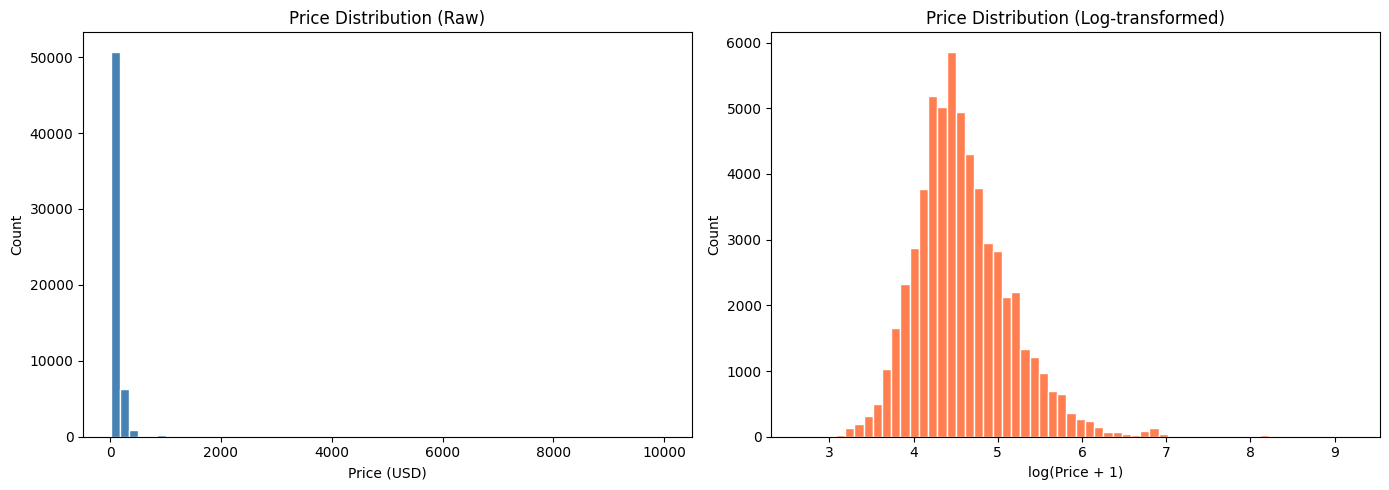

Price stats:
count    58500.000000
mean       121.797350
std        210.917076
min         13.000000
25%         66.000000
50%         90.000000
75%        133.000000
max      10000.000000
Name: price, dtype: float64

Listings with price > $500: 582


In [ ]:
# Checking the Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(merged_df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

# Log transformed price to handle extreme outliers
axes[1].hist(np.log1p(merged_df['price']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Price stats:\n{merged_df['price'].describe()}")
print(f"\nListings with price > $500: {(merged_df['price'] > 500).sum()}")

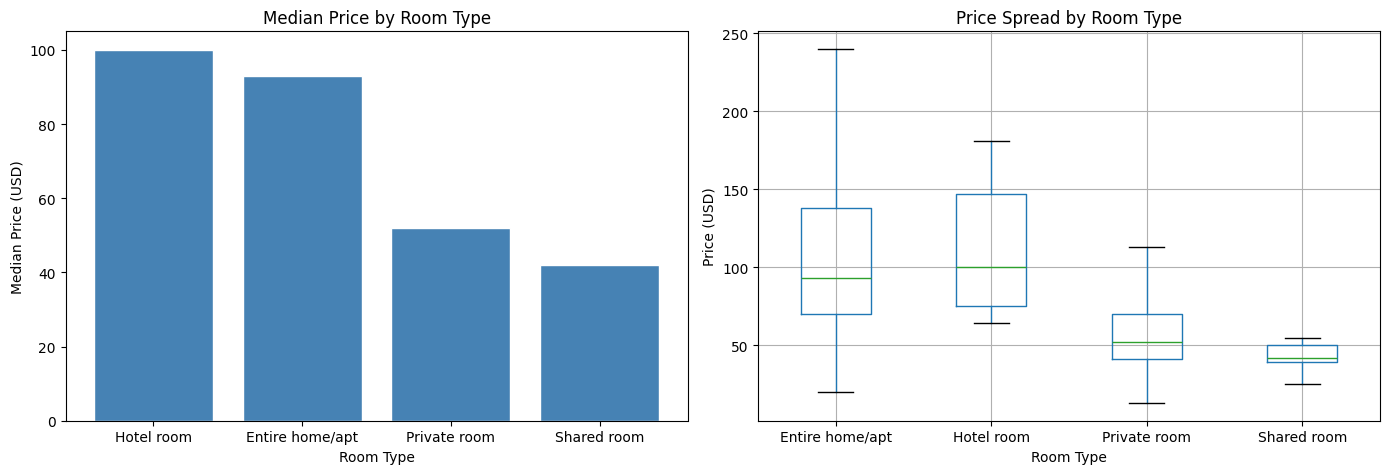

In [ ]:
# Price by Room Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_avg = merged_df.groupby('room_type')['price'].median().sort_values(ascending=False)

axes[0].bar(room_avg.index, room_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Median Price (USD)')

# Boxplot to show spread
merged_df.boxplot(column='price', by='room_type', ax=axes[1],
                  showfliers=False)  # showfliers=False hides extreme outliers for readability
axes[1].set_title('Price Spread by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price (USD)')
plt.suptitle('')  # removes the default pandas boxplot title

plt.tight_layout()
plt.show()

/tmp/ipykernel_10879/2970953537.py:13: UserWarning: Glyph 154 (\x9a) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10879/2970953537.py:13: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 154 (\x9a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


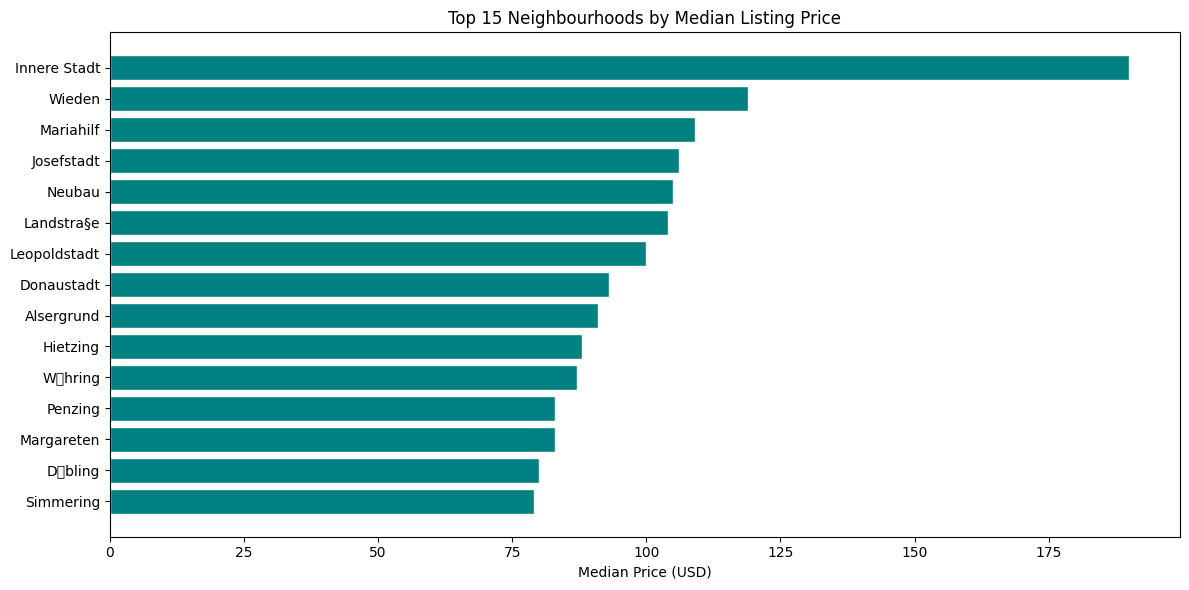

In [ ]:
#Top Neighbourhoods by Median Price
top_neighbourhoods = (
    merged_df.groupby('neighbourhood_cleansed')['price']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.barh(top_neighbourhoods.index[::-1], top_neighbourhoods.values[::-1], color='teal', edgecolor='white')
plt.title('Top 15 Neighbourhoods by Median Listing Price')
plt.xlabel('Median Price (USD)')
plt.tight_layout()
plt.show()

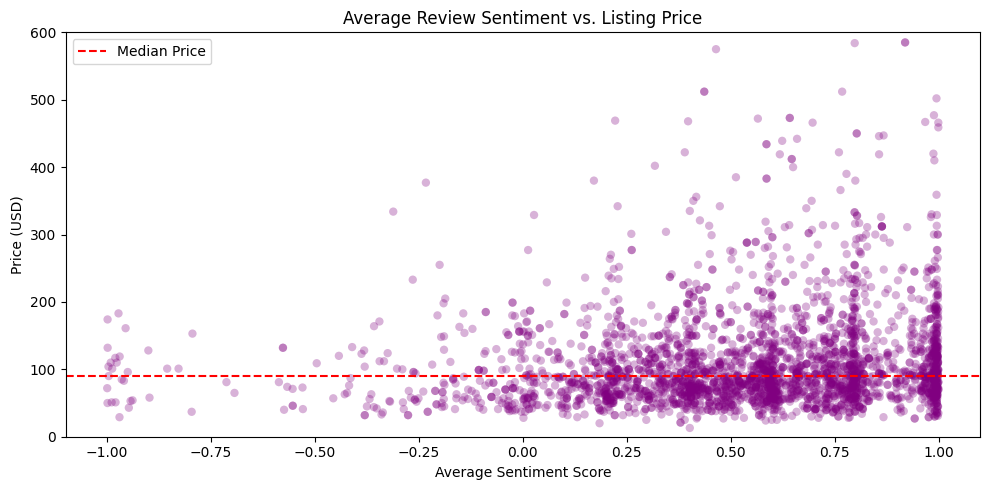

Correlation between sentiment and price: 0.016


In [ ]:
# Sentiment vs Price
# Using a sample so the plot isn't overloaded with 58,500 points
sample = merged_df.sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['avg_sentiment'], sample['price'], alpha=0.3, color='purple', edgecolor='none')
plt.title('Average Review Sentiment vs. Listing Price')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Price (USD)')
plt.ylim(0, 600)  # cap y-axis so outliers don't compress the main data
plt.axhline(merged_df['price'].median(), color='red', linestyle='--', label='Median Price')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between sentiment and price: {merged_df['avg_sentiment'].corr(merged_df['price']):.3f}")

## Feature Engineering

In [ ]:
#Working on a clean copy so we don't mess up merged_df
model_df = merged_df.copy()

#Counting the number of amenities each listing has
model_df['amenity_count'] = model_df['amenities'].apply(
    lambda x: len(x.split(',')) if isinstance(x, str) else 0
)
print(model_df['amenity_count'])

0        56
1        56
2        56
3        56
4        56
         ..
58495    14
58496    32
58497    32
58498    15
58499    15
Name: amenity_count, Length: 58500, dtype: int64


In [ ]:
# Converting instant_bookable (t/f text) to a binary number
model_df['instant_bookable'] = (model_df['instant_bookable'] == 't').astype(int)

In [ ]:
#Droping columns that are NOT useful for predicting price
cols_to_drop = ['listing_id', 'date', 'comments', 'cleaned_comments',
                'first_review', 'last_review', 'language', 'amenities','estimated_revenue_l365d']
model_df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
#One-hot encoding categorical text columns
model_df = pd.get_dummies(model_df, columns=['room_type', 'neighbourhood_cleansed', 'property_type'], drop_first=True)


In [ ]:
print(f"Shape after feature engineering: {model_df.shape}")
print(f"\nColumn list (first 30):\n{list(model_df.columns[:30])}")

Shape after feature engineering: (58500, 87)

Column list (first 30):
['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'number_of_reviews_ltm', 'availability_eoy', 'estimated_occupancy_l365d', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'review_length', 'avg_sentiment', 'topic_loc_and_comf', 'topic_host', 'topic_sentiment', 'topic_transport', 'amenity_count', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_cleansed_Brigittenau', 'neighbourhood_cleansed_Donaustadt', 'neighbourhood_cleansed_D\x9abling', 'neighbourhood_cleansed_Favoriten', 'neighbourhood_cleansed_Floridsdorf']


<Axes: >

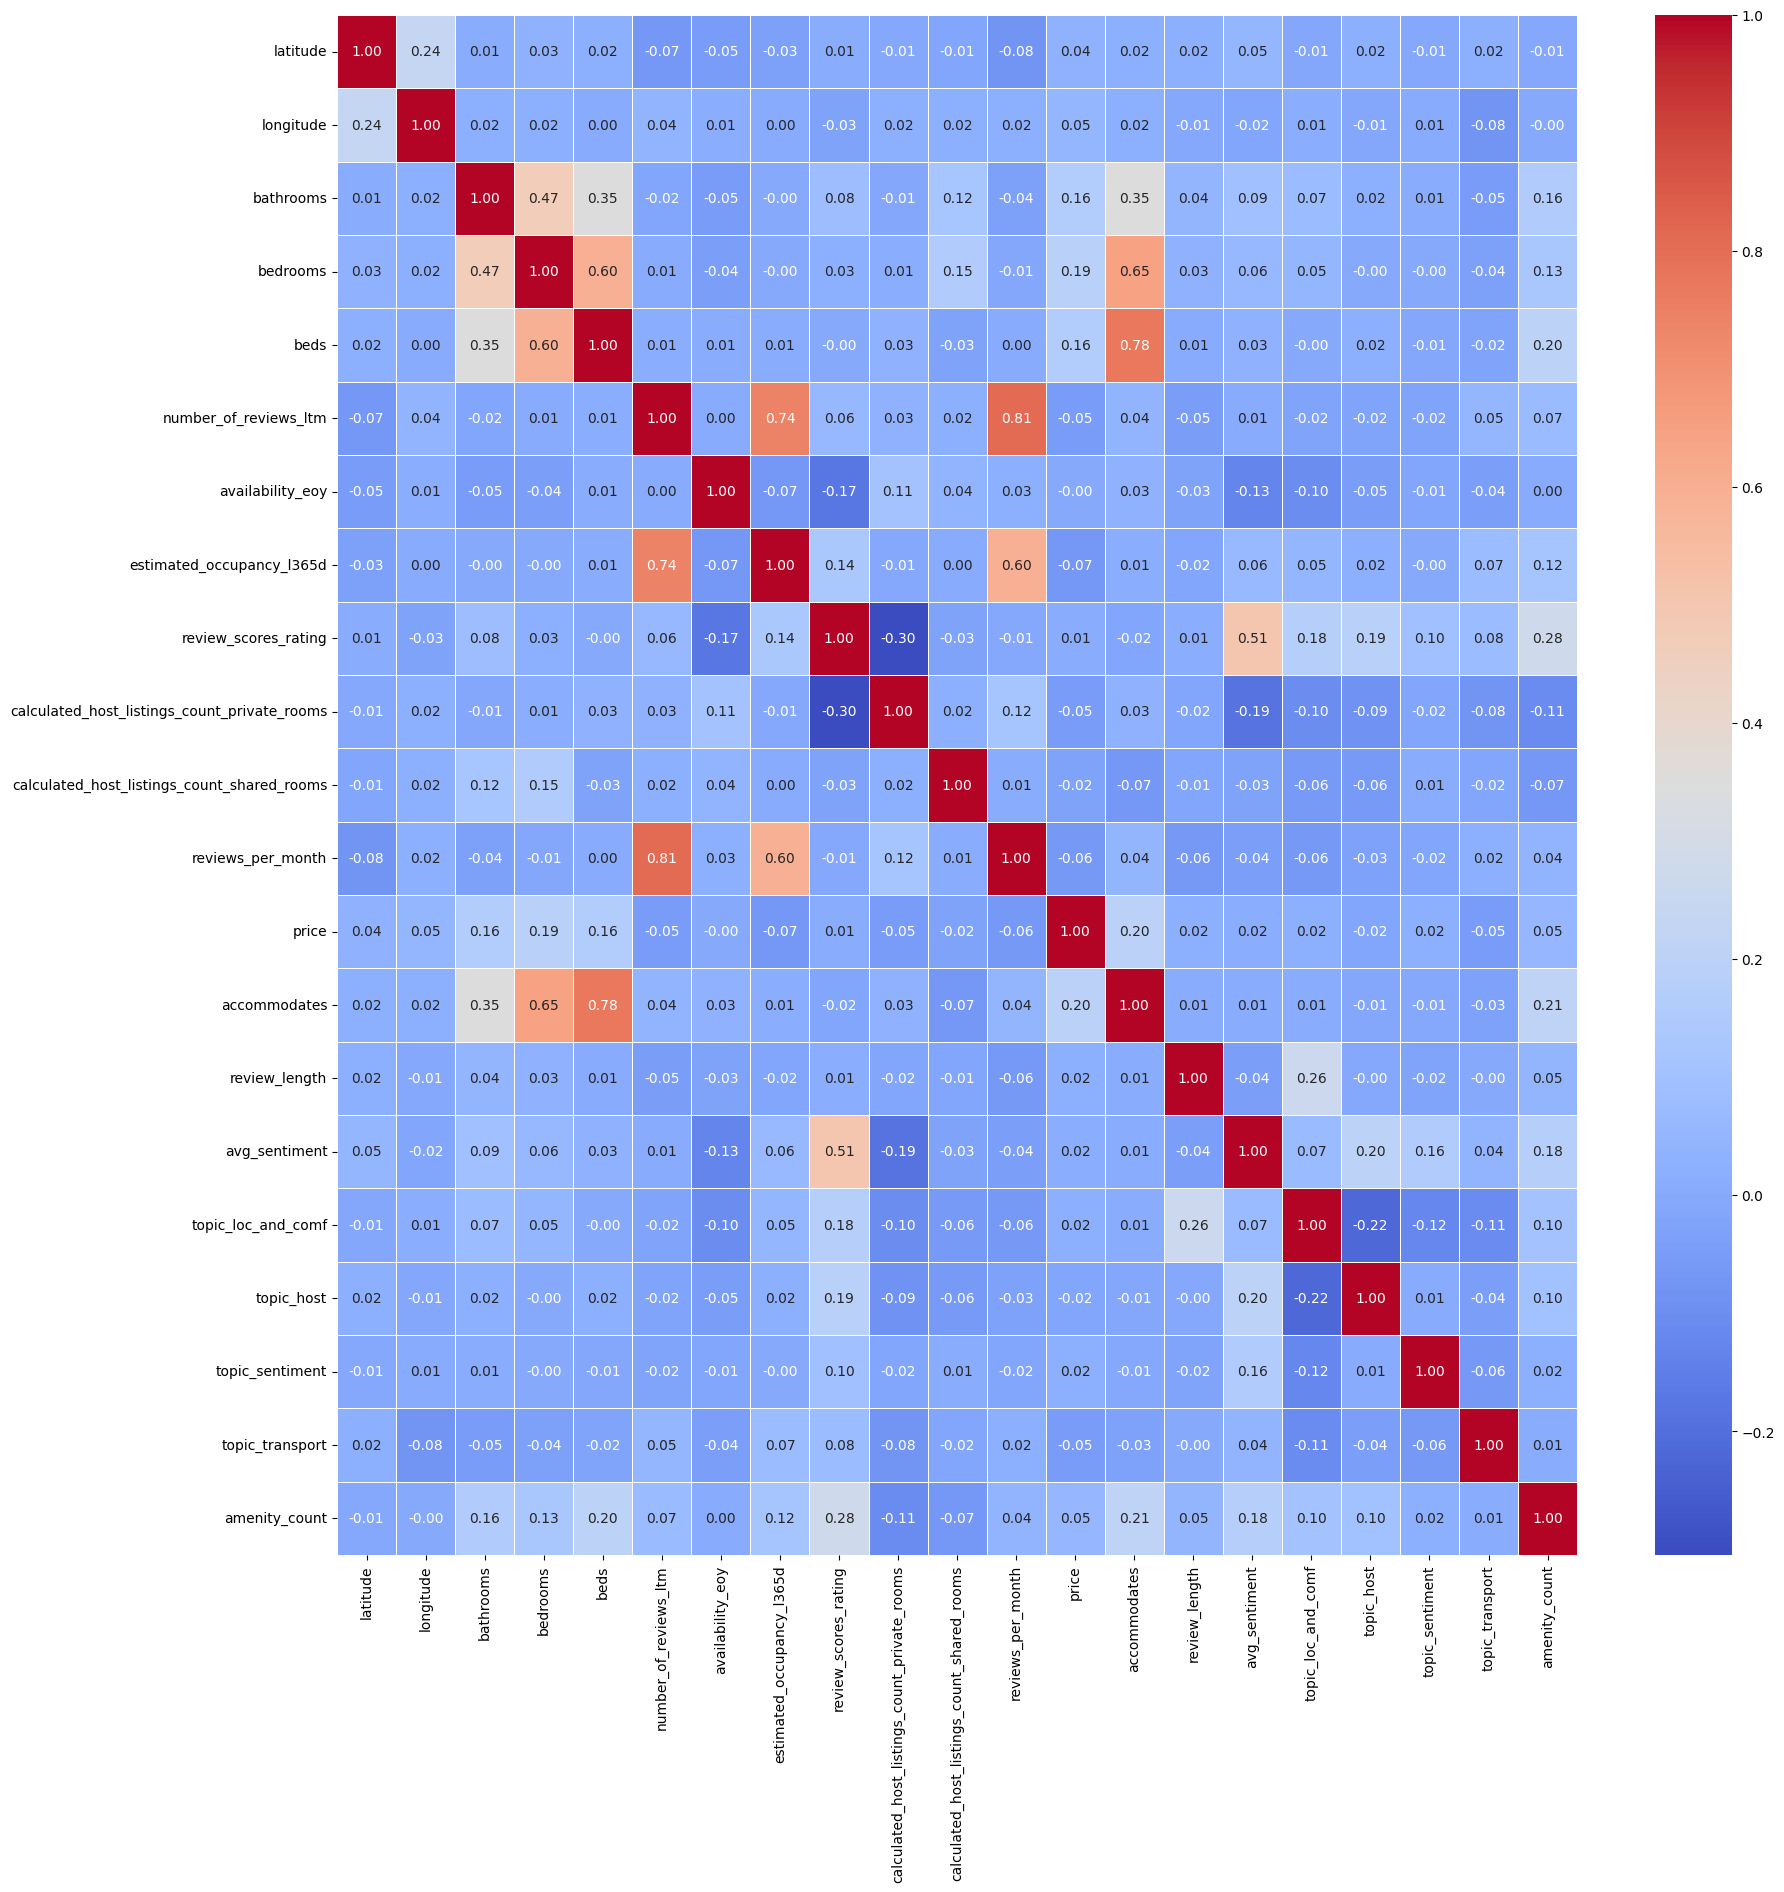

In [ ]:
# With amenity count,
#Generating a correlation heatmap with the undropped columns AND AMENITIES
num_cols = ['latitude', 'longitude', 'bathrooms', 'bedrooms', 'beds',
'number_of_reviews_ltm',
'availability_eoy',
'estimated_occupancy_l365d',
'review_scores_rating',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month','price','accommodates',
'review_length','avg_sentiment',
"topic_loc_and_comf", "topic_host",
"topic_sentiment","topic_transport","amenity_count"]

#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(model_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')
#sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, vmin = -1, vmax = 1) Can use to adust gradient

## Test Train Split

In [ ]:
# Target Variable & Train/Test Split
from sklearn.model_selection import train_test_split

# Log-transforming price to reduce the skewness
model_df['log_price'] = np.log1p(model_df['price'])

# Defining features (X) and target (y)
X = model_df.drop(columns=['price', 'log_price'])
y = model_df['log_price']

In [ ]:
# Split: 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (46800, 86)
Test set size:     (11700, 86)


## Standardization

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fitting only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standardization complete.")
print(f"Mean of first feature in training set (should be ~0): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std  of first feature in training set (should be ~1): {X_train_scaled[:, 0].std():.4f}")

Standardization complete.
Mean of first feature in training set (should be ~0): -0.0000
Std  of first feature in training set (should be ~1): 1.0000


## Linear regression

In [ ]:
# Linear Regression Baseline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Ridge regression = Linear regression with a small penalty to prevent overfitting
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Results:")
print(f"  RMSE (log scale): {rmse_ridge:.4f}")
print(f"  R² Score:         {r2_ridge:.4f}")

# Convert predictions back from log scale to actual dollars for interpretability
actual_prices    = np.expm1(y_test)
predicted_prices = np.expm1(y_pred_ridge)
rmse_dollars = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f"  RMSE (dollars):   ${rmse_dollars:.2f}")

Ridge Regression Results:
  RMSE (log scale): 0.3980
  R² Score:         0.5132
  RMSE (dollars):   $231.92


In [ ]:
#  Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the network
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
nn_model.summary()

# Early stopping: stop training if validation loss stops improving for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,   # use 10% of training data to monitor overfitting
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,505 (84.00 KB)

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 3.9926 - mae: 1.4227 - val_loss: 0.6546 - val_mae: 0.6569
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2465 - mae: 0.8566 - val_loss: 0.7226 - val_mae: 0.7251
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8811 - mae: 0.7187 - val_loss: 0.7951 - val_mae: 0.7823
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6965 - mae: 0.6406 - val_loss: 0.7949 - val_mae: 0.7839
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5743 - mae: 0.5793 - val_loss: 0.6882 - val_mae: 0.7157
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4828 - mae: 0.5309 - val_loss: 0.7096 - val_mae: 0.7287
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3967 - mae: 0.4806 - val_loss: 0.6723 - val_mae: 0.7069
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3408 - mae: 0.4412 - val_loss: 0.6180 - val_mae: 0.6657
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

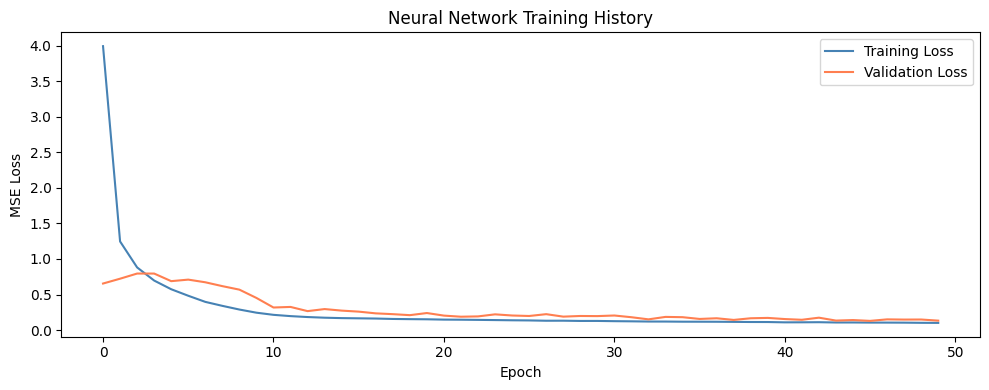

In [ ]:
# Training History
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral')
plt.title('Neural Network Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Neural Network Evaluation
y_pred_nn_log = nn_model.predict(X_test_scaled).flatten()

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn_log))
r2_nn   = r2_score(y_test, y_pred_nn_log)

print(f"Neural Network Results:")
print(f"  RMSE (log scale): {rmse_nn:.4f}")
print(f"  R² Score:         {r2_nn:.4f}")

predicted_prices_nn = np.expm1(y_pred_nn_log)
rmse_nn_dollars = np.sqrt(mean_squared_error(actual_prices, predicted_prices_nn))
print(f"  RMSE (dollars):   ${rmse_nn_dollars:.2f}")

# Side-by-side comparison
print(f"\n{'Model':<25} {'RMSE (log)':<15} {'R²':<10} {'RMSE ($)'}")
print("-" * 60)
print(f"{'Ridge Regression':<25} {rmse_ridge:<15.4f} {r2_ridge:<10.4f} ${rmse_dollars:.2f}")
print(f"{'Neural Network':<25} {rmse_nn:<15.4f} {r2_nn:<10.4f} ${rmse_nn_dollars:.2f}")

366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Network Results:
  RMSE (log scale): 0.3521
  R² Score:         0.6190
  RMSE (dollars):   $210.08

Model                     RMSE (log)      R²         RMSE ($)
------------------------------------------------------------
Ridge Regression          0.3980          0.5132     $231.92
Neural Network            0.3521          0.6190     $210.08


In [ ]:
#Feature importance of NN model
from sklearn.inspection import permutation_importance
import pandas as pd
result=permutation_importance(
    nn_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=4,
    scoring="neg_mean_squared_error"
)
importances=pd.Series(result.importances_mean, index=X.columns)
top20= importances.reindex(importances.abs().sort_values(ascending=False).index).head(20)
print(top20)

366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
366/366 ━━━━━━━━

In [ ]:
top20_pos=top20[top20>0]
top20_neg=top20[top20<0]

/tmp/ipykernel_10879/3645916137.py:6: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


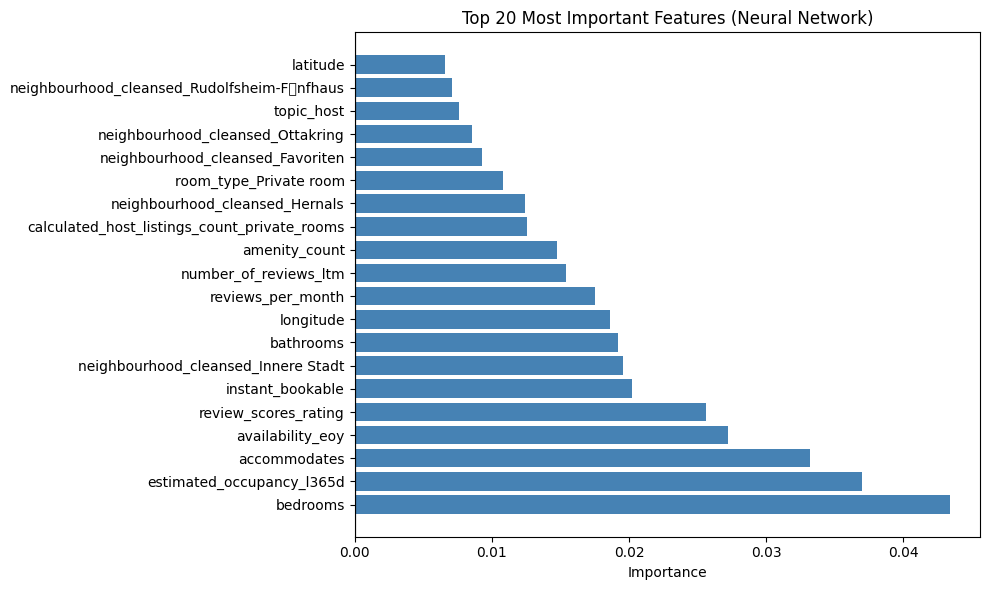

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top20_pos.index, top20_pos.values, label='Positive', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Most Important Features (Neural Network)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

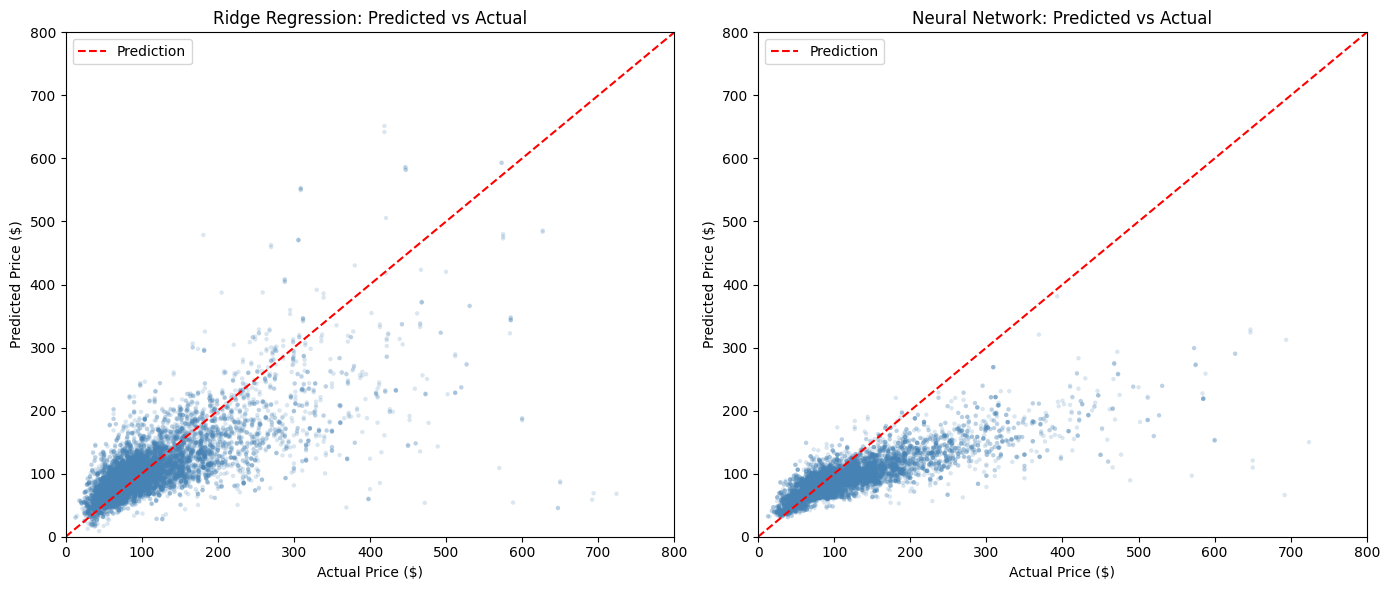

In [ ]:
# Block 12: Predicted vs Actual Price
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title in zip(
    axes,
    [np.expm1(y_pred_ridge), predicted_prices_nn],
    ['Ridge Regression', 'Neural Network']
):
    ax.scatter(actual_prices, preds, alpha=0.2, color='steelblue', edgecolor='none', s=10)
    max_val = min(actual_prices.max(), 800)
    ax.plot([0, max_val], [0, max_val], 'r--', label='Prediction')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{title}: Predicted vs Actual')
    ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_10879/4082607621.py:18: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  plt.tight_layout()


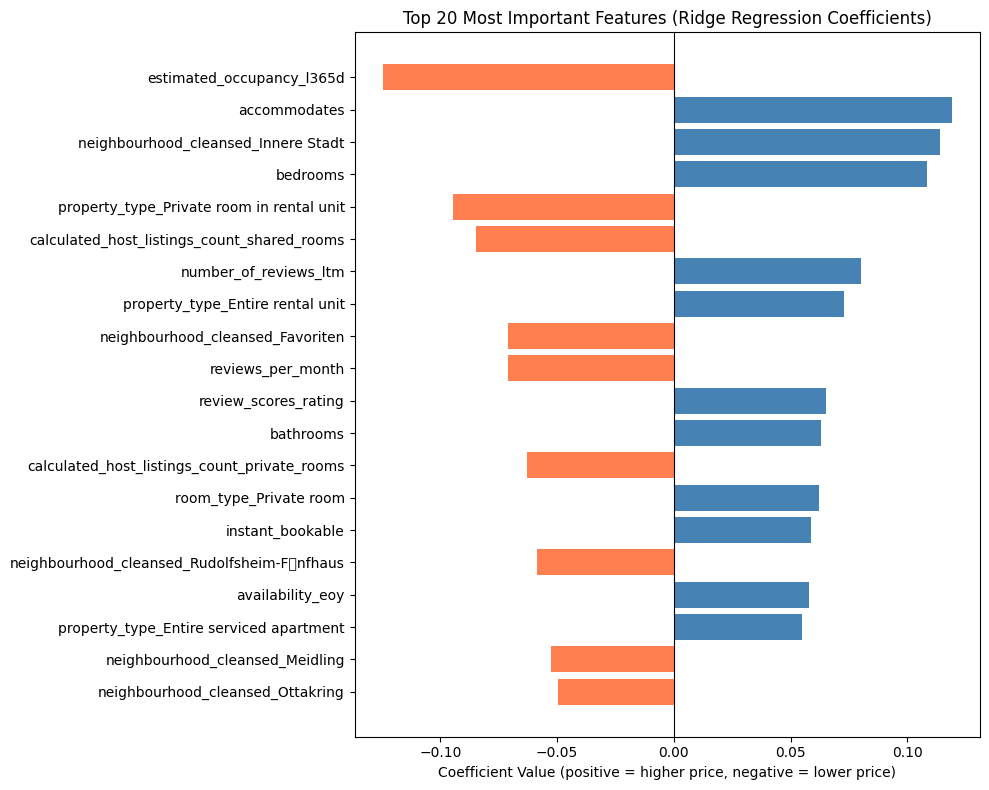

In [ ]:
# Feature Importance (Ridge Coefficients)
feature_names = X.columns.tolist()
coefficients  = ridge.coef_

importance_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)

top20 = importance_df.head(20)

plt.figure(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in top20['Coefficient']]
plt.barh(top20['Feature'][::-1], top20['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Most Important Features (Ridge Regression Coefficients)')
plt.xlabel('Coefficient Value (positive = higher price, negative = lower price)')
plt.tight_layout()
plt.show()